In [1]:
# 50 признаков

import warnings
warnings.filterwarnings('ignore')

import os
import io
import time
import json
import shutil
import zipfile
import requests

import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.ticker import MaxNLocator
from rich.progress import track
from pathlib import Path

from scipy.signal import find_peaks
from scipy.stats import kurtosis, skew, pearsonr
from scipy.signal.windows import blackman

from sklearn.feature_selection import RFECV
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold
from sklearn.preprocessing import PowerTransformer, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, StackingClassifier, VotingClassifier


# Конвертер numpy типов для JSON
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        
        if isinstance(obj, np.integer):
            return int(obj)
            
        if isinstance(obj, np.floating):
            return float(obj)
            
        if isinstance(obj, np.ndarray):
            return obj.tolist()
            
        return super().default(obj)


def prepare_data(features_df, binary=False, test_size=0.2, scaler_type=None, random_state=42):

    train_dfs = []
    test_dfs = []
    
    # Группируем по исходным классам (0, 1, 2, 3, 4, 5)
    for class_id in sorted(features_df["Класс"].unique()):
        class_data = features_df[features_df["Класс"] == class_id]
        
        # Определяем точку среза (индекс 80%)
        split_idx = int(len(class_data) * (1 - test_size))
        
        # Первые 80% — в обучение, последние 20% — в тест
        train_dfs.append(class_data.iloc[:split_idx])
        test_dfs.append(class_data.iloc[split_idx:])
    
    # Собираем всё обратно
    train_df = pd.concat(train_dfs).reset_index(drop=True)
    test_df = pd.concat(test_dfs).reset_index(drop=True)
    
    # Разделяем на X и y
    X_train = train_df.drop(columns=["Класс"])
    y_train = train_df["Класс"].values
    
    X_test = test_df.drop(columns=["Класс"])
    y_test = test_df["Класс"].values

    X_train = X_train[features]
    X_test = X_test[features]
    
    # Если нужна бинарная классификация (0 - норма, 1 - авария)
    if binary:
        y_train = (y_train != 0).astype(int)
        y_test = (y_test != 0).astype(int)

    # Для SVM, KNN, Logistic Regression 
    if scaler_type == "standard":
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    # Для нейросетей
    elif scaler_type == "minmax":
        scaler = MinMaxScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    # Если есть выбросы
    elif scaler_type == "robust":
        scaler = RobustScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    # Если данные не нормально распределены (скошенные)
    elif scaler_type == "power":
        power = PowerTransformer(method="yeo-johnson")
        X_train = power.fit_transform(X_train)
        X_test = power.transform(X_test)

    return X_train, X_test, y_train, y_test


def train_and_evaluate(models, all_results, results_key, X_train_raw, X_test_raw, X_train_std, X_test_std, y_train, y_test):
    
    trained_models = {}
    ensamble_models = ["CatBoost", "XGBoost", "LightGBM"]
    
    for model_name, model in models.items():
        
        # Выбор подходящих данных для конкретной модели
        if model_name in ["K-Nearest Neighbors", "Logistic Regression"]:
            X_train, X_test = X_train_std, X_test_std
        else:
            X_train, X_test = X_train_raw, X_test_raw

        print("-" * 53)
        print(f"\n{model_name}")
        
        # Обучение
        start_train = time.perf_counter()
        model.fit(X_train, y_train)
        training_time = time.perf_counter() - start_train
        
        # Сохраняем обученную модель, если она используется в Stacking и Voting
        if model_name in ensamble_models:
            trained_models[model_name] = model
        
        # Инференс
        start_predict = time.perf_counter()
        y_pred = model.predict(X_test)
        predict_time = time.perf_counter() - start_predict

        # Расчет метрик качества
        accuracy = accuracy_score(y_test, y_pred) * 100
        precision = precision_score(y_test, y_pred, average="weighted") * 100
        recall = recall_score(y_test, y_pred, average="weighted") * 100
        f1 = f1_score(y_test, y_pred, average="weighted") * 100

        # Время на одно предсказание (в миллисекундах)
        time_per_pred = predict_time / len(y_test) * 1000

        # Сохранение результатов
        all_results[results_key][model_name] = {
            "Accuracy": round(accuracy, 3),
            "Precision": round(precision, 3),
            "Recall": round(recall, 3),
            "F1_Score": round(f1, 3),
            "Training_Time": round(training_time, 2),
            "Inference_Time": round(predict_time, 4),
            "Time_per_pred_ms": round(time_per_pred, 4)
        }

        all_results[results_key][model_name]["Confusion_Matrix"] = confusion_matrix(y_test, y_pred).tolist()
        
        # Вывод результатов
        print(f"Время обучения: {training_time:.3f} с")
        print(f"Время инференса: {predict_time:.3f} с, {time_per_pred:.4f} мс на 1 предсказание\n")
        print(classification_report(y_test, y_pred))
        print(f"Accuracy:\t{accuracy:.2f} %")
        
    return trained_models, all_results


In [8]:
overlaps = [50, 75]             # Перекрытия окон (%)
window_sizes = [64, 32, 16, 8]  # Размеры окон

with open("DATA/rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    file = json.load(f)

features = file["optimal_features"][:50]

# Получение списка CSV-файлов с извлеченными признаками
file_names = [name for name in os.listdir("DATA/features") 
              if name.endswith('.csv') and
              any(f"ws{w}" in name for w in window_sizes) and
              any(f"overlap{o}" in name for o in overlaps)]

# Сортировка сначала по убыванию размера окна, затем по возрастанию перекрытия
file_names = sorted(
    file_names,
    key=lambda x: (-int(x.split('_')[2].replace('ws', '')), 
                   int(x.split('_')[3].replace('overlap', '').replace('.csv', '')))
)

all_results = {}   # Словарь для всех результатов
random_state = 42  # Фиксируем random_state для воспроизводимости

for file_name in file_names:
    print(f"\n\n{'=' * 53}")
    print(f"ОБРАБОТКА ФАЙЛА: {file_name}")
    print('=' * 53)

    # Загрузка данных
    features_df = pd.read_csv(f"DATA/features/{file_name}")
    
    print(len(features_df))
    print("\nДанные загружены")

    # Подготовка данных без масштабирования
    X_train_raw, X_test_raw, y_train, y_test = prepare_data(features_df, binary=False, test_size=0.2, scaler_type=None, random_state=random_state)
    
    # Подготовка данных с использованием StandardScaler 
    X_train_std, X_test_std, _, _ = prepare_data(features_df, test_size=0.2, scaler_type="standard", random_state=random_state)
    print("Предобработка и разбиение на train/test завершены\n")

    # Инициализация базовых моделей
    models = {
        "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=37, leaf_size=1, p=1, metric='manhattan', weights='uniform'),
        "Logistic Regression": LogisticRegression(random_state=random_state),
        "Histogram-based Gradient Boosting": HistGradientBoostingClassifier(random_state=random_state),
        "XGBoost": XGBClassifier(random_state=random_state, device="cuda", tree_method="hist", n_jobs=-1),
        "LightGBM": LGBMClassifier(verbose=-1, random_state=random_state)
    }

    # Инициализация хранилища результатов
    results_key = f"{file_name}"
    all_results[results_key] = {}

    # Обучение базовых моделей
    trained_models, all_results = train_and_evaluate(models, all_results, results_key, X_train_raw, X_test_raw, X_train_std, X_test_std, y_train, y_test)


# Сохранение результатов обучения в json файл
with open('DATA/related_info/models_binary_training_results.json', 'w', encoding='utf-8') as f:
    json.dump(all_results, f, indent=4, cls=NumpyEncoder, ensure_ascii=False)
print(f"\nРезультаты сохранены в json файл")




ОБРАБОТКА ФАЙЛА: REAL_features_ws64_overlap50.csv
4154

Данные загружены
Предобработка и разбиение на train/test завершены

-----------------------------------------------------

K-Nearest Neighbors
Время обучения: 0.001 с
Время инференса: 1.495 с, 1.7926 мс на 1 предсказание

              precision    recall  f1-score   support

           0       0.99      0.94      0.97       119
           1       0.98      0.99      0.99       190
           2       0.74      0.87      0.80       129
           3       0.95      0.66      0.78       124
           4       0.82      0.93      0.87       138
           5       0.90      0.90      0.90       134

    accuracy                           0.89       834
   macro avg       0.90      0.88      0.88       834
weighted avg       0.90      0.89      0.89       834

Accuracy:	89.21 %
-----------------------------------------------------

Logistic Regression
Время обучения: 0.046 с
Время инференса: 0.000 с, 0.0002 мс на 1 предсказание

     

In [34]:
# Бинарная классификация + отобранные признаки (TOP-50)

import warnings
warnings.filterwarnings('ignore')

import os
import time
import json
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# =========================
# JSON encoder для numpy
# =========================
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)


# =========================
# Подготовка данных
# =========================
def prepare_data(features_df, binary=True, chronological=False, selected_features=None, test_size=0.2, scaler_type=None, random_state=42):

    if chronological:
        train_dfs = []
        test_dfs = []
    
        for class_id in sorted(features_df["Класс"].unique()):
            class_data = features_df[features_df["Класс"] == class_id]
            split_idx = int(len(class_data) * (1 - test_size))
    
            train_dfs.append(class_data.iloc[:split_idx])
            test_dfs.append(class_data.iloc[split_idx:])
    
        train_df = pd.concat(train_dfs).reset_index(drop=True)
        test_df = pd.concat(test_dfs).reset_index(drop=True)
    
        X_train = train_df.drop(columns=["Класс"])
        y_train = train_df["Класс"].values
    
        X_test = test_df.drop(columns=["Класс"])
        y_test = test_df["Класс"].values

    else:
        X = features_df.drop(columns=["Класс"])
        y = features_df["Класс"].values
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=random_state)

    if selected_features is not None:
        selected_features = [f for f in selected_features if f in X_train.columns]
        X_train = X_train[selected_features]
        X_test = X_test[selected_features]

    if binary:
        y_train = (y_train != 0).astype(int)
        y_test = (y_test != 0).astype(int)

    if scaler_type == "standard":
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test


# =========================
# Обучение и оценка
# =========================
def train_and_evaluate(models, results, key, X_train_raw, X_test_raw, X_train_std, X_test_std, y_train, y_test):

    for model_name, model in models.items():

        if model_name in ["K-Nearest Neighbors", "Logistic Regression"]:
            X_train, X_test = X_train_std, X_test_std
        else:
            X_train, X_test = X_train_raw, X_test_raw

        print("-" * 50)
        print(model_name)

        # Обучение
        start = time.perf_counter()
        model.fit(X_train, y_train)
        train_time = time.perf_counter() - start

        # Предсказание
        start = time.perf_counter()
        y_pred = model.predict(X_test)
        infer_time = time.perf_counter() - start

        # Метрики
        acc = accuracy_score(y_test, y_pred) * 100
        prec = precision_score(y_test, y_pred, average="weighted") * 100
        rec = recall_score(y_test, y_pred, average="weighted") * 100
        f1 = f1_score(y_test, y_pred, average="weighted") * 100

        time_per_pred = infer_time / len(y_test) * 1000

        results[key][model_name] = {
            "Accuracy": round(acc, 3),
            "Precision": round(prec, 3),
            "Recall": round(rec, 3),
            "F1_Score": round(f1, 3),
            "Training_Time": round(train_time, 3),
            "Inference_Time": round(infer_time, 4),
            "Time_per_pred_ms": round(time_per_pred, 4),
            "Confusion_Matrix": confusion_matrix(y_test, y_pred).tolist()
        }

        print(f"Accuracy: {acc:.3f}%")
        print(classification_report(y_test, y_pred))

    return results


# =========================
# Загрузка TOP-50 признаков
# =========================
with open("DATA/rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    file = json.load(f)

features = file["optimal_features"][:50]


# =========================
# Основной цикл
# =========================
overlaps = [75]
window_sizes = [32]

file_names = [name for name in os.listdir("DATA/features")
              if name.endswith('.csv') and
              any(f"ws{w}" in name for w in window_sizes) and
              any(f"overlap{o}" in name for o in overlaps)]

file_names = sorted(
    file_names,
    key=lambda x: (-int(x.split('_')[2].replace('ws', '')),
                   round(float(x.split('_')[3].replace('overlap', '').replace('.csv', '')), 3))
)

results = {}
random_state = 0


for file_name in file_names:

    # print(f"\n{'='*50}")
    # print(f"ФАЙЛ: {file_name}")
    # print('='*50)

    df = pd.read_csv(f"DATA/features/{file_name}")

    # Без масштабирования
    X_train_raw, X_test_raw, y_train, y_test = prepare_data(
        df,
        selected_features=features,
        binary=True,
        scaler_type=None,
        chronological=True, 
        random_state=random_state
    )

    # Со StandardScaler
    X_train_std, X_test_std, _, _ = prepare_data(
        df,
        selected_features=features,
        binary=True,
        scaler_type="standard",
        chronological=True, 
        random_state=random_state
    )

    models = {
        # "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=37, p=1, metric='manhattan'),
        # "Logistic Regression": LogisticRegression(max_iter=1000),
        # "Histogram-based Gradient Boosting": HistGradientBoostingClassifier(),
        "XGBoost": XGBClassifier(device="cuda", tree_method="hist", n_jobs=-1, max_depth=7),
        # "LightGBM": LGBMClassifier(verbose=-1)
    }

    results[file_name] = {}

    results = train_and_evaluate(
        models,
        results,
        file_name,
        X_train_raw,
        X_test_raw,
        X_train_std,
        X_test_std,
        y_train,
        y_test
    )

    random_state += 1



# =========================
# Сохранение результатов
# =========================
with open('DATA/related_info/models_binary_top50_results.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=4, cls=NumpyEncoder, ensure_ascii=False)

print("\nГотово: результаты сохранены")



--------------------------------------------------
XGBoost
Accuracy: 99.009%
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       477
           1       0.99      1.00      0.99      2854

    accuracy                           0.99      3331
   macro avg       0.99      0.97      0.98      3331
weighted avg       0.99      0.99      0.99      3331


Готово: результаты сохранены


In [134]:
random_state

1

In [15]:
results['REAL_features_ws32_overlap75.csv']['XGBoost']['Accuracy']

98.979

## НЕбинарная классиыикация

Загружено 50 признаков из RFECV
Загружено 133071 строк данных
Train size: (106455, 50), Test size: (26616, 50)
Class distribution in test:
class 0: 3808
class 1: 6074
class 2: 4114
class 3: 3958
class 4: 4394
class 5: 4268


NameError: name 'ax2' is not defined

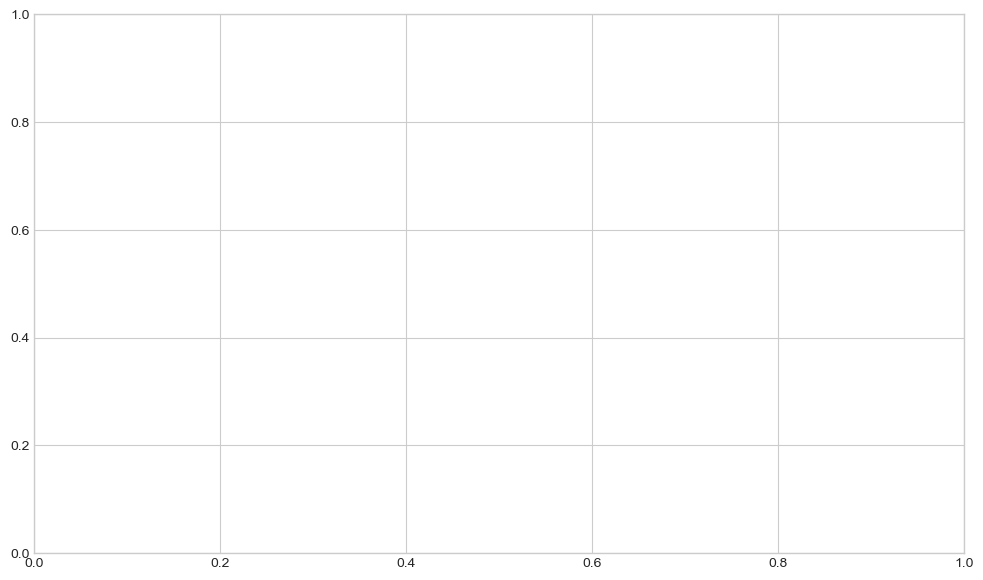

In [2]:
# 50 признаков

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score
import os
import json

# 1. Функция хронологического разделения (80/20)
def prepare_data_chronological(df, test_size=0.2, binary=False, selected_features=None):
    train_dfs = []
    test_dfs = []
    
    # Группируем по исходным классам для честного разделения
    for class_id in sorted(df["Класс"].unique()):
        class_data = df[df["Класс"] == class_id]
        split_idx = int(len(class_data) * (1 - test_size))
        
        train_dfs.append(class_data.iloc[:split_idx])
        test_dfs.append(class_data.iloc[split_idx:])
    
    train_df = pd.concat(train_dfs).reset_index(drop=True)
    test_df = pd.concat(test_dfs).reset_index(drop=True)
    
    # Отбор признаков
    if selected_features is None:
        # Если список не задан, берем все, кроме целевой колонки
        selected_features = [c for c in train_df.columns if c != "Класс"]
    
    X_train = train_df[selected_features]
    X_test = test_df[selected_features]
    
    y_train = train_df["Класс"].values
    y_test = test_df["Класс"].values
    
    if binary:
        y_train = (y_train != 0).astype(int)
        y_test = (y_test != 0).astype(int)
        
    return X_train, X_test, y_train, y_test

# 2. Основной блок выполнения
# Путь к вашему лучшему файлу (например, ws32 overlap75)
file_path = "DATA/features/REAL_features_ws32_overlap96.875.csv" 

# ЗАГРУЗКА ПРИЗНАКОВ ИЗ RFECV
with open("DATA/rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    file = json.load(f)

features = file["optimal_features"][:50]
print(f"Загружено {len(features)} признаков из RFECV")

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"Загружено {len(df)} строк данных")
    
    # используем отобранные признаки
    X_train, X_test, y_train, y_test = prepare_data_chronological(df, selected_features=features)
    
    print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
    
    print("Class distribution in test:")
    for c in np.unique(y_test):
        print(f"class {c}: {sum(y_test == c)}")

    # Обучение модели
    model = XGBClassifier(
        random_state=42,
        verbose=-1,
        # objective='binary',
    )
    model.fit(X_train, y_train)

    # 3. Анализ порогов уверенности (Reject Option)
    probs = model.predict_proba(X_test)
    
    sorted_probs = np.sort(probs, axis=1)
    confidences = sorted_probs[:, -1] - sorted_probs[:, -2] ####################################
    
    base_preds = np.argmax(probs, axis=1)

    thresholds = np.linspace(0.0, 0.99, 1000)               ############################################
    results = []

    for t in thresholds:
        # Маска для тех предсказаний, где модель "уверена"
        mask = confidences >= t
        
        coverage = np.mean(mask) * 100 # Процент данных, которые модель не "отбросила"
        
        if np.any(mask):
            acc = accuracy_score(y_test[mask], base_preds[mask]) * 100
        else:
            acc = None # Если модель не уверена ни в чем
            
        results.append({
            "Threshold": t,
            "Accuracy": acc,
            "Coverage": coverage
        })

    df_res = pd.DataFrame(results).dropna()

    # 4. Визуализация компромисса Точность / Покрытие
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax1 = plt.subplots(figsize=(12, 7))

     # ========== НАСТРОЙКИ ОТСТУПОВ ==========
    # Отступы для подписей осей (больше значение = дальше от оси)
    ax1.xaxis.labelpad = 15    # Отступ для подписи оси X
    ax1.yaxis.labelpad = 15    # Отступ для подписи левой оси Y
    ax2.yaxis.labelpad = 15    # Отступ для подписи правой оси Y
    
    # Отступ для заголовка графика
    plt.title('XGBoost: Влияние порога уверенности на точность детектирования\n(Хронологическое разделение 80/20, 50 лучших признаков)', 
              fontsize=16, fontweight='bold', pad=20)
    
    # Ось для Точности (левая)
    color_acc = '#27ae60'
    ax1.set_xlabel('Порог уверенности (Confidence Threshold)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Точность на выбранных данных (Accuracy %)', color=color_acc, fontsize=14, fontweight='bold')
    line1 = ax1.plot(df_res["Threshold"], df_res["Accuracy"], color=color_acc, linewidth=4, label='Точность (Accuracy)')
    ax1.tick_params(axis='y', labelcolor=color_acc, labelsize=12)
    
    # Ось для Покрытия (правая)
    ax2 = ax1.twinx()
    color_cov = '#2980b9'
    ax2.set_ylabel('Покрытие выборки (Coverage %)', color=color_cov, fontsize=14, fontweight='bold')
    line2 = ax2.plot(df_res["Threshold"], df_res["Coverage"], color=color_cov, linewidth=4, linestyle='-', label='Покрытие (Coverage)')
    ax2.tick_params(axis='y', labelcolor=color_cov, labelsize=12)

    # x_min, x_max = 0.48, 1.02
    
    # # ========== НАСТРОЙКА ОСИ АБСЦИСС ==========
    # # Устанавливаем диапазон и шаг для оси X
    # ax1.set_xlim(x_min, x_max)
    
    # Создаем деления для оси X с заданным шагом
    x_ticks = np.arange(0, 1.05, 0.1)
    ax1.set_xticks(x_ticks)
    ax1.set_xticklabels([round(x, 2) for x in x_ticks], fontsize=12)###########################################################################################################
    ax1.tick_params(axis='x', pad=8)
    
    # === СИНХРОНИЗАЦИЯ ОСЕЙ ===
    # Задаем диапазоны для обеих осей
    acc_min, acc_max = 88, 98  # Диапазон для точности (подберите под свои данные)
    cov_min, cov_max = 68, 100   # Диапазон для покрытия
    
    ax1.set_ylim(acc_min, acc_max)
    ax2.set_ylim(cov_min, cov_max)
    
    # Количество делений (включая границы)
    n_ticks = 8  # 7 делений = 6 интервалов
    
    # Создаем одинаковые деления для левой оси
    acc_ticks = np.linspace(acc_min, acc_max, n_ticks)
    ax1.set_yticks(acc_ticks)
    ax1.set_yticklabels([round(x, 2) for x in acc_ticks])
    
    # Для правой оси создаем деления с тем же шагом, но в другом диапазоне
    # Вычисляем коэффициент преобразования
    # cov = k * acc + b
    # При acc_min -> cov_min, acc_max -> cov_max
    k = (cov_max - cov_min) / (acc_max - acc_min)
    b = cov_min - k * acc_min
    
    # Преобразуем левые деления в правые
    cov_ticks = k * acc_ticks + b
    ax2.set_yticks(cov_ticks)
    ax2.set_yticklabels([round(x, 2) for x in cov_ticks])
    
    # Опционально: включаем сетку только для левой оси, чтобы избежать двойной сетки
    ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.5, color='black')
    ax2.grid(False)
    
    # Объединение легенд
    lns = line1 + line2
    labs = [l.get_label() for l in lns]
    ax1.legend(lns, labs, loc='lower left', fontsize=14, frameon=True, shadow=True)

    plt.tight_layout()
    plt.savefig('confidence_tradeoff_lgbm_50features.png', dpi=600)
    plt.show()

    # Вывод контрольных точек
    print(f"\nРезультаты при разных порогах:")
    print(f"При пороге 0.50 (без фильтрации): Accuracy = {df_res.iloc[0]['Accuracy']:.2f}%, Coverage = {df_res.iloc[0]['Coverage']:.1f}%")
    
    # Поиск ближайшего порога к 0.95
    idx_95 = (df_res['Threshold'] - 0.95).abs().idxmin()
    print(f"При пороге {df_res.iloc[idx_95]['Threshold']:.3f}: Accuracy = {df_res.iloc[idx_95]['Accuracy']:.2f}%, Coverage = {df_res.iloc[idx_95]['Coverage']:.1f}%")
    
    # Лучший компромисс (максимальная точность при покрытии > 50%)
    high_acc = df_res[df_res['Coverage'] > 50].sort_values('Accuracy', ascending=False).iloc[0]
    print(f"Лучший компромисс (Coverage > 50%): порог={high_acc['Threshold']:.3f}, Accuracy={high_acc['Accuracy']:.2f}%, Coverage={high_acc['Coverage']:.1f}%")

else:
    print(f"Файл данных не найден: {file_path}")
    print("Проверьте путь к CSV файлу.")

## Бинарная классиыикация

Загружено 50 признаков из RFECV
Загружено 16639 строк данных
Train size: (13308, 50), Test size: (3331, 50)
Class distribution in test: 0=477, 1=2854


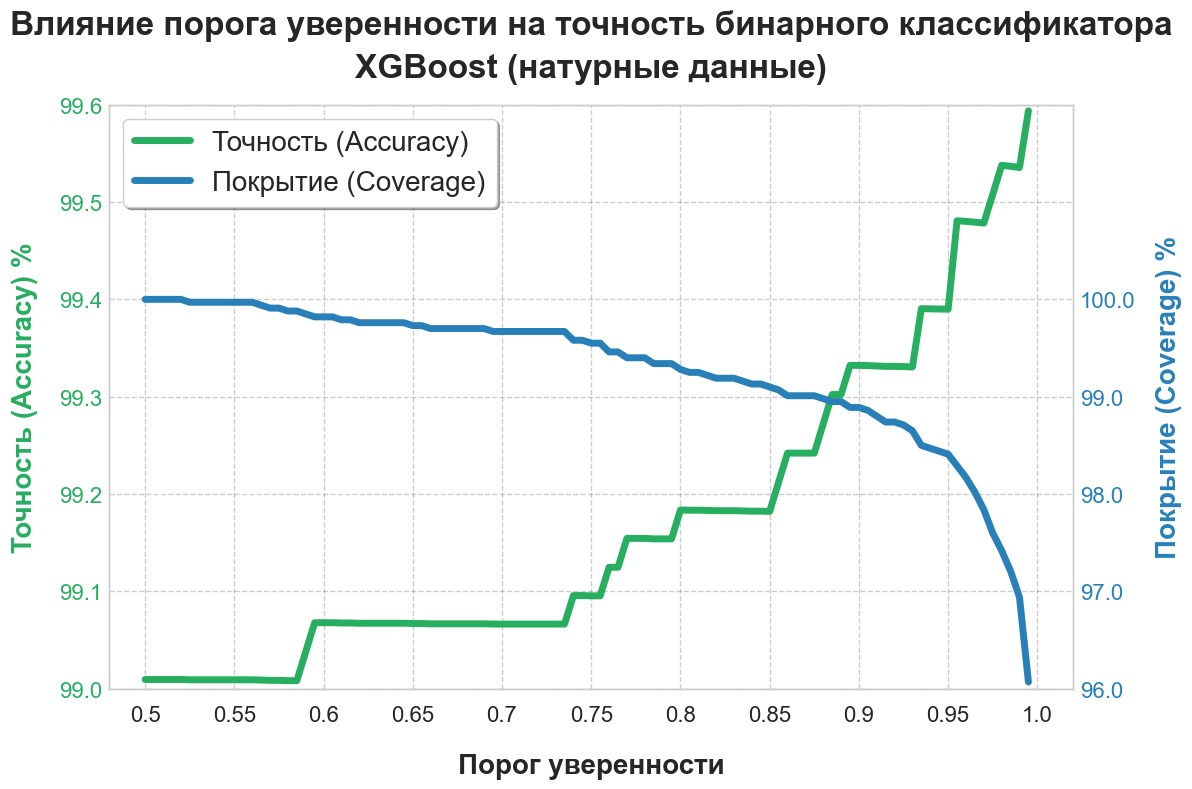


Результаты при разных порогах:
При пороге 0.50 (без фильтрации): Accuracy = 99.01%, Coverage = 100.0%
При пороге 0.950: Accuracy = 99.39%, Coverage = 98.4%
Лучший компромисс (Coverage > 50%): порог=0.995, Accuracy=99.59%, Coverage=96.1%


In [2]:
# 50 признаков

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier  # <--- ДОБАВИТЬ ЭТУ СТРОКУ
from sklearn.metrics import accuracy_score
import os
import json

# 1. Функция хронологического разделения (80/20)
def prepare_data(features_df, binary=True, chronological=False, selected_features=None, test_size=0.2, scaler_type=None, random_state=42):

    if chronological:
        train_dfs = []
        test_dfs = []
    
        for class_id in sorted(features_df["Класс"].unique()):
            class_data = features_df[features_df["Класс"] == class_id]
            split_idx = int(len(class_data) * (1 - test_size))
    
            train_dfs.append(class_data.iloc[:split_idx])
            test_dfs.append(class_data.iloc[split_idx:])
    
        train_df = pd.concat(train_dfs).reset_index(drop=True)
        test_df = pd.concat(test_dfs).reset_index(drop=True)
    
        X_train = train_df.drop(columns=["Класс"])
        y_train = train_df["Класс"].values
    
        X_test = test_df.drop(columns=["Класс"])
        y_test = test_df["Класс"].values

    else:
        X = features_df.drop(columns=["Класс"])
        y = features_df["Класс"].values
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=random_state)

    if selected_features is not None:
        selected_features = [f for f in selected_features if f in X_train.columns]
        X_train = X_train[selected_features]
        X_test = X_test[selected_features]

    if binary:
        y_train = (y_train != 0).astype(int)
        y_test = (y_test != 0).astype(int)

    if scaler_type == "standard":
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test

# 2. Основной блок выполнения
# Путь к вашему лучшему файлу (например, ws32 overlap75)
file_path = "DATA/features/REAL_features_ws32_overlap75.csv" 

# ЗАГРУЗКА ПРИЗНАКОВ ИЗ RFECV
with open("DATA/rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    file = json.load(f)

features = file["optimal_features"][:50]
print(f"Загружено {len(features)} признаков из RFECV")

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"Загружено {len(df)} строк данных")
    
    X_train, X_test, y_train, y_test = prepare_data(df, binary=True, chronological=True, selected_features=features)
    
    print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
    print(f"Class distribution in test: 0={sum(y_test==0)}, 1={sum(y_test==1)}")

    # Обучение модели
    model = XGBClassifier(device="cuda", tree_method="hist", n_jobs=-1, max_depth=7, random_state=42)
    model.fit(X_train, y_train)

    # 3. Анализ порогов уверенности (Reject Option)
    probs = model.predict_proba(X_test)
    confidences = np.max(probs, axis=1) # Максимальная вероятность из двух классов
    base_preds = np.argmax(probs, axis=1)

    thresholds = np.linspace(0.5, 0.995, 100)
    results = []

    for t in thresholds:
        # Маска для тех предсказаний, где модель "уверена"
        mask = confidences >= t
        
        coverage = np.mean(mask) * 100 # Процент данных, которые модель не "отбросила"
        
        if np.any(mask):
            acc = accuracy_score(y_test[mask], base_preds[mask]) * 100
        else:
            acc = None # Если модель не уверена ни в чем
            
        results.append({
            "Threshold": t,
            "Accuracy": acc,
            "Coverage": coverage
        })

    df_res = pd.DataFrame(results).dropna()

    # 4. Визуализация компромисса Точность / Покрытие
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax1 = plt.subplots(figsize=(12, 8))

    # ========== НАСТРОЙКИ ОТСТУПОВ ==========
    ax1.xaxis.labelpad = 15
    ax1.yaxis.labelpad = 15
    
    plt.title('Влияние порога уверенности на точность бинарного классификатора\nXGBoost (натурные данные)', 
              fontsize=24, fontweight='bold', pad=20, linespacing=1.5)
    
    # Ось для Точности (левая)
    color_acc = '#27ae60'
    ax1.set_xlabel('Порог уверенности', fontsize=20, fontweight='bold', labelpad=20)
    ax1.set_ylabel('Точность (Accuracy) %', color=color_acc, fontsize=20, fontweight='bold')
    line1 = ax1.plot(df_res["Threshold"], df_res["Accuracy"], color=color_acc, linewidth=5, label='Точность (Accuracy)')
    ax1.tick_params(axis='y', labelcolor=color_acc, labelsize=12, pad=5)
    
    # Ось для Покрытия (правая)
    ax2 = ax1.twinx()
    ax2.yaxis.labelpad = 15
    
    color_cov = '#2980b9'
    ax2.set_ylabel('Покрытие (Coverage) %', color=color_cov, fontsize=20, fontweight='bold')
    line2 = ax2.plot(df_res["Threshold"], df_res["Coverage"], color=color_cov, linewidth=5, linestyle='-', label='Покрытие (Coverage)')
    ax2.tick_params(axis='y', labelcolor=color_cov, labelsize=12, pad=5)

    x_min, x_max = 0.48, 1.02
    
    # Настройка оси X
    ax1.set_xlim(x_min, x_max)
    x_ticks = np.arange(0.5, 1.05, 0.05)
    ax1.set_xticks(x_ticks)
    ax1.set_xticklabels([round(x, 2) for x in x_ticks], fontsize=16)
    ax1.tick_params(axis='x', pad=12)
    
    # === СИНХРОНИЗАЦИЯ ОСЕЙ С ОТКЛЮЧЕНИЕМ ВЕРХНИХ ДВУХ ДЕЛЕНИЙ ===
    acc_min, acc_max = 99, 99.6
    cov_min, cov_max = 96, 102

    n_ticks = 7  # Всего 7 делений
    
    ax1.set_ylim(acc_min, acc_max)
    ax2.set_ylim(cov_min, cov_max)
    
    # Деления для левой оси (все 7)
    acc_ticks = np.linspace(acc_min, acc_max, n_ticks)
    ax1.set_yticks(acc_ticks)
    ax1.set_yticklabels([round(x, 2) for x in acc_ticks], fontsize=16)
    
    # Для правой оси: вычисляем все 7 делений
    k = (cov_max - cov_min) / (acc_max - acc_min)
    b = cov_min - k * acc_min
    cov_ticks_all = k * acc_ticks + b
    
    # Оставляем только первые 5 делений (скрываем последние 2)
    n_display_ticks = n_ticks - 2  # 5 делений
    cov_ticks_display = cov_ticks_all[:n_display_ticks]
    cov_labels = [round(x, 2) for x in cov_ticks_display]
    
    # Устанавливаем тики и метки на правой оси
    ax2.set_yticks(cov_ticks_display)
    ax2.set_yticklabels(cov_labels, fontsize=16)
    
    # Сетка
    ax1.grid(True, alpha=0.2, linestyle='--', linewidth=1, color='black')
    ax2.grid(False)
    
    # Легенда
    lns = line1 + line2
    labs = [l.get_label() for l in lns]
    ax1.legend(lns, labs, loc='upper left', fontsize=20, frameon=True, shadow=True)

    plt.tight_layout()
    plt.savefig('binary_confidence_tradeoff_xgb_50features.png', dpi=600)
    plt.show()
    # Вывод контрольных точек
    print(f"\nРезультаты при разных порогах:")
    print(f"При пороге 0.50 (без фильтрации): Accuracy = {df_res.iloc[0]['Accuracy']:.2f}%, Coverage = {df_res.iloc[0]['Coverage']:.1f}%")
    
    # Поиск ближайшего порога к 0.95
    idx_95 = (df_res['Threshold'] - 0.95).abs().idxmin()
    print(f"При пороге {df_res.iloc[idx_95]['Threshold']:.3f}: Accuracy = {df_res.iloc[idx_95]['Accuracy']:.2f}%, Coverage = {df_res.iloc[idx_95]['Coverage']:.1f}%")
    
    # Лучший компромисс (максимальная точность при покрытии > 50%)
    high_acc = df_res[df_res['Coverage'] > 50].sort_values('Accuracy', ascending=False).iloc[0]
    print(f"Лучший компромисс (Coverage > 50%): порог={high_acc['Threshold']:.3f}, Accuracy={high_acc['Accuracy']:.2f}%, Coverage={high_acc['Coverage']:.1f}%")

else:
    print(f"Файл данных не найден: {file_path}")
    print("Проверьте путь к CSV файлу.")

## НЕбинарная

Загружено 50 признаков из RFECV
Загружено 16639 строк данных
97.11538461538461


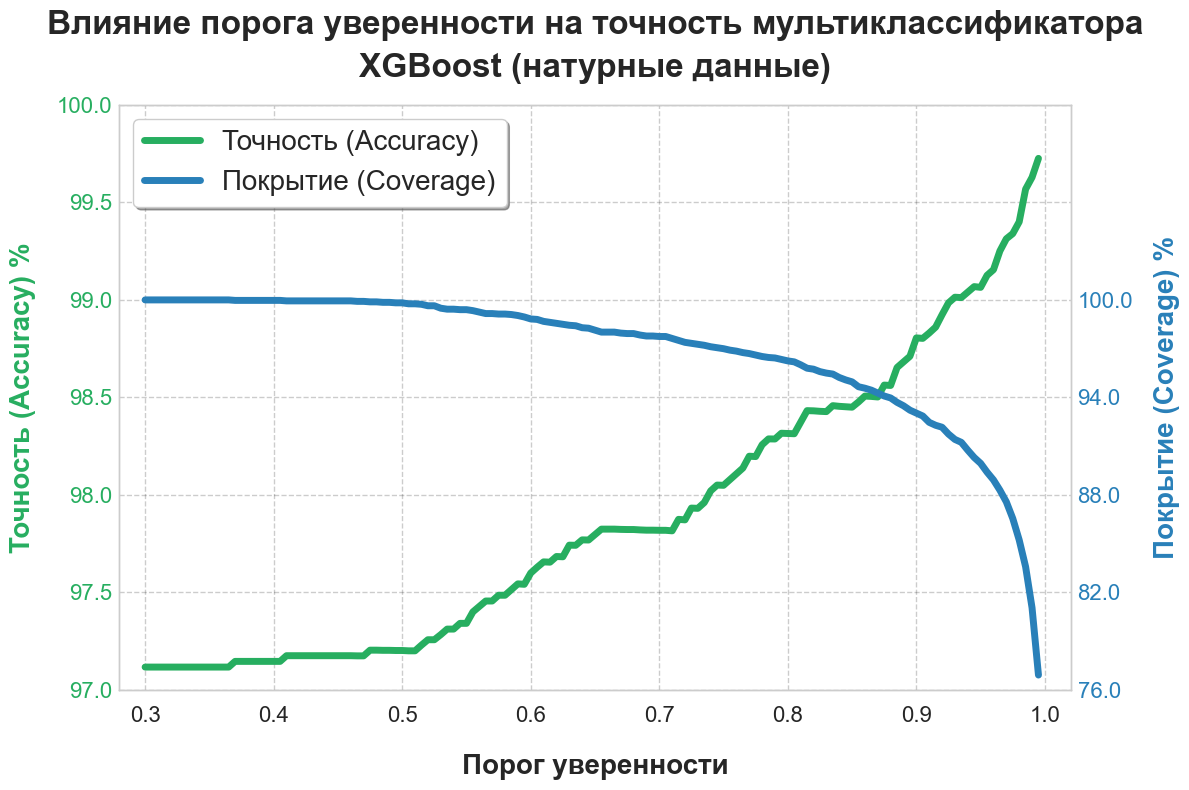


Результаты при разных порогах:
При пороге 0.50 (без фильтрации): Accuracy = 97.12%, Coverage = 100.0%
При пороге 0.950: Accuracy = 99.06%, Coverage = 89.9%
Лучший компромисс (Coverage > 50%): порог=0.995, Accuracy=99.73%, Coverage=76.9%


In [3]:
# 50 признаков

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier  # <--- ДОБАВИТЬ ЭТУ СТРОКУ
from sklearn.metrics import accuracy_score
import os
import json
from sklearn.model_selection import train_test_split

# 1. Функция хронологического разделения (80/20)
def prepare_data(features_df, binary=True, chronological=False, selected_features=None, test_size=0.2, scaler_type=None, random_state=42):

    if chronological:
        train_dfs = []
        test_dfs = []
    
        for class_id in sorted(features_df["Класс"].unique()):
            class_data = features_df[features_df["Класс"] == class_id]
            split_idx = int(len(class_data) * (1 - test_size))
    
            train_dfs.append(class_data.iloc[:split_idx])
            test_dfs.append(class_data.iloc[split_idx:])
    
        train_df = pd.concat(train_dfs).reset_index(drop=True)
        test_df = pd.concat(test_dfs).reset_index(drop=True)
    
        X_train = train_df.drop(columns=["Класс"])
        y_train = train_df["Класс"].values
    
        X_test = test_df.drop(columns=["Класс"])
        y_test = test_df["Класс"].values

    else:
        X = features_df.drop(columns=["Класс"])
        y = features_df["Класс"].values
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=random_state)

    if selected_features is not None:
        selected_features = [f for f in selected_features if f in X_train.columns]
        X_train = X_train[selected_features]
        X_test = X_test[selected_features]

    if binary:
        y_train = (y_train != 0).astype(int)
        y_test = (y_test != 0).astype(int)

    if scaler_type == "standard":
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test

# 2. Основной блок выполнения
# Путь к вашему лучшему файлу (например, ws32 overlap75)
file_path = "DATA/features/REAL_features_ws32_overlap75.csv" 

# ЗАГРУЗКА ПРИЗНАКОВ ИЗ RFECV
with open("DATA/rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    file = json.load(f)

features = file["optimal_features"][:50]
print(f"Загружено {len(features)} признаков из RFECV")
accuracy = 0
random_state = 1
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"Загружено {len(df)} строк данных")

    while accuracy <= 97:
        X_train, X_test, y_train, y_test = prepare_data(df, binary=False, chronological=False, selected_features=features, random_state=random_state)
    
    
        # Обучение модели
        model = XGBClassifier(device="cuda", tree_method="hist", n_jobs=-1, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred) * 100
        random_state += 1
        print(accuracy)

    # 3. Анализ порогов уверенности (Reject Option)
    probs = model.predict_proba(X_test)
    confidences = np.max(probs, axis=1) # Максимальная вероятность из двух классов
    base_preds = np.argmax(probs, axis=1)

    thresholds = np.linspace(0.3, 0.995, 140)
    results = []

    for t in thresholds:
        # Маска для тех предсказаний, где модель "уверена"
        mask = confidences >= t
        
        coverage = np.mean(mask) * 100 # Процент данных, которые модель не "отбросила"
        
        if np.any(mask):
            acc = accuracy_score(y_test[mask], base_preds[mask]) * 100
        else:
            acc = None # Если модель не уверена ни в чем
            
        results.append({
            "Threshold": t,
            "Accuracy": acc,
            "Coverage": coverage
        })

    df_res = pd.DataFrame(results).dropna()

    # 4. Визуализация компромисса Точность / Покрытие
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax1 = plt.subplots(figsize=(12, 8))

    # ========== НАСТРОЙКИ ОТСТУПОВ ==========
    ax1.xaxis.labelpad = 15
    ax1.yaxis.labelpad = 15
    
    plt.title('Влияние порога уверенности на точность мультиклассификатора\nXGBoost (натурные данные)', 
              fontsize=24, fontweight='bold', pad=20, linespacing=1.5)
    
    # Ось для Точности (левая)
    color_acc = '#27ae60'
    ax1.set_xlabel('Порог уверенности', fontsize=20, fontweight='bold', labelpad=20)
    ax1.set_ylabel('Точность (Accuracy) %', color=color_acc, fontsize=20, fontweight='bold')
    line1 = ax1.plot(df_res["Threshold"], df_res["Accuracy"], color=color_acc, linewidth=5, label='Точность (Accuracy)')
    ax1.tick_params(axis='y', labelcolor=color_acc, labelsize=12, pad=5)
    
    # Ось для Покрытия (правая)
    ax2 = ax1.twinx()
    ax2.yaxis.labelpad = 15
    
    color_cov = '#2980b9'
    ax2.set_ylabel('Покрытие (Coverage) %', color=color_cov, fontsize=20, fontweight='bold')
    line2 = ax2.plot(df_res["Threshold"], df_res["Coverage"], color=color_cov, linewidth=5, linestyle='-', label='Покрытие (Coverage)')
    ax2.tick_params(axis='y', labelcolor=color_cov, labelsize=12, pad=5)

    x_min, x_max = 0.28, 1.02
    
    # Настройка оси X
    ax1.set_xlim(x_min, x_max)
    x_ticks = np.arange(0.3, 1.05, 0.1)
    ax1.set_xticks(x_ticks)
    ax1.set_xticklabels([round(x, 2) for x in x_ticks], fontsize=16)
    ax1.tick_params(axis='x', pad=12)
    
    # === СИНХРОНИЗАЦИЯ ОСЕЙ С ОТКЛЮЧЕНИЕМ ВЕРХНИХ ДВУХ ДЕЛЕНИЙ ===
    acc_min, acc_max = 97, 100
    cov_min, cov_max = 76, 112

    n_ticks = 7  # Всего 7 делений
    
    ax1.set_ylim(acc_min, acc_max)
    ax2.set_ylim(cov_min, cov_max)
    
    # Деления для левой оси (все 7)
    acc_ticks = np.linspace(acc_min, acc_max, n_ticks)
    ax1.set_yticks(acc_ticks)
    ax1.set_yticklabels([round(x, 2) for x in acc_ticks], fontsize=16)
    
    # Для правой оси: вычисляем все 7 делений
    k = (cov_max - cov_min) / (acc_max - acc_min)
    b = cov_min - k * acc_min
    cov_ticks_all = k * acc_ticks + b
    
    # Оставляем только первые 5 делений (скрываем последние 2)
    n_display_ticks = n_ticks - 2  # 5 делений
    cov_ticks_display = cov_ticks_all[:n_display_ticks]
    cov_labels = [round(x, 2) for x in cov_ticks_display]
    
    # Устанавливаем тики и метки на правой оси
    ax2.set_yticks(cov_ticks_display)
    ax2.set_yticklabels(cov_labels, fontsize=16)
    
    # Сетка
    ax1.grid(True, alpha=0.2, linestyle='--', linewidth=1, color='black')
    ax2.grid(False)
    
    # Легенда
    lns = line1 + line2
    labs = [l.get_label() for l in lns]
    ax1.legend(lns, labs, loc='upper left', fontsize=20, frameon=True, shadow=True)

    plt.tight_layout()
    plt.savefig('multi_confidence_tradeoff_xgb_50features.png', dpi=600)
    plt.show()
    # Вывод контрольных точек
    print(f"\nРезультаты при разных порогах:")
    print(f"При пороге 0.50 (без фильтрации): Accuracy = {df_res.iloc[0]['Accuracy']:.2f}%, Coverage = {df_res.iloc[0]['Coverage']:.1f}%")
    
    # Поиск ближайшего порога к 0.95
    idx_95 = (df_res['Threshold'] - 0.95).abs().idxmin()
    print(f"При пороге {df_res.iloc[idx_95]['Threshold']:.3f}: Accuracy = {df_res.iloc[idx_95]['Accuracy']:.2f}%, Coverage = {df_res.iloc[idx_95]['Coverage']:.1f}%")
    
    # Лучший компромисс (максимальная точность при покрытии > 50%)
    high_acc = df_res[df_res['Coverage'] > 50].sort_values('Accuracy', ascending=False).iloc[0]
    print(f"Лучший компромисс (Coverage > 50%): порог={high_acc['Threshold']:.3f}, Accuracy={high_acc['Accuracy']:.2f}%, Coverage={high_acc['Coverage']:.1f}%")

else:
    print(f"Файл данных не найден: {file_path}")
    print("Проверьте путь к CSV файлу.")

## Буфер окон


In [98]:
# 50 признаков

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score
import json

# 1. Подготовка данных (Хронологический сплит)
def prepare_data_chronological(df, test_size=0.2, binary=True):
    train_dfs, test_dfs = [], []
    for class_id in sorted(df["Класс"].unique()):
        class_data = df[df["Класс"] == class_id]
        split_idx = int(len(class_data) * (1 - test_size))
        train_dfs.append(class_data.iloc[:split_idx])
        test_dfs.append(class_data.iloc[split_idx:])
    
    train_df = pd.concat(train_dfs).reset_index(drop=True)
    test_df = pd.concat(test_dfs).reset_index(drop=True)
    
    X_train = train_df.drop(columns=["Класс"])
    X_test = test_df.drop(columns=["Класс"])
    y_train = train_df["Класс"].values
    y_test = test_df["Класс"].values
    
    if binary:
        y_train = (y_train != 0).astype(int)
        y_test = (y_test != 0).astype(int)
    return X_train, X_test, y_train, y_test

# 2. Функция мажоритарного голосования в скользящем окне
def apply_rolling_predictions(y_pred, window_size=5):
    smoothed_preds = []
    for i in range(len(y_pred)):
        start_idx = max(0, i - window_size + 1)
        buffer = y_pred[start_idx : i + 1]
        final_vote = 1 if np.mean(buffer) > 0.5 else 0
        smoothed_preds.append(final_vote)
    return np.array(smoothed_preds)

# --- ОСНОВНОЙ ЦИКЛ ---
file_path = "DATA/features/REAL_features_ws32_overlap96.875.csv" #96.875
df = pd.read_csv(file_path)

with open("DATA/rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    file = json.load(f)

features = file["optimal_features"][:50]

# Исправленная передача признаков
df_filtered = df[features + ["Класс"]]
X_train, X_test, y_train, y_test = prepare_data_chronological(df_filtered)

# Обучение модели
model = XGBClassifier(device="cuda", tree_method="hist", n_jobs=-1, max_depth=7, random_state=42)
model.fit(X_train, y_train)

# Получаем базовые предсказания
y_pred_raw = model.predict(X_test)
raw_accuracy = accuracy_score(y_test, y_pred_raw) * 100


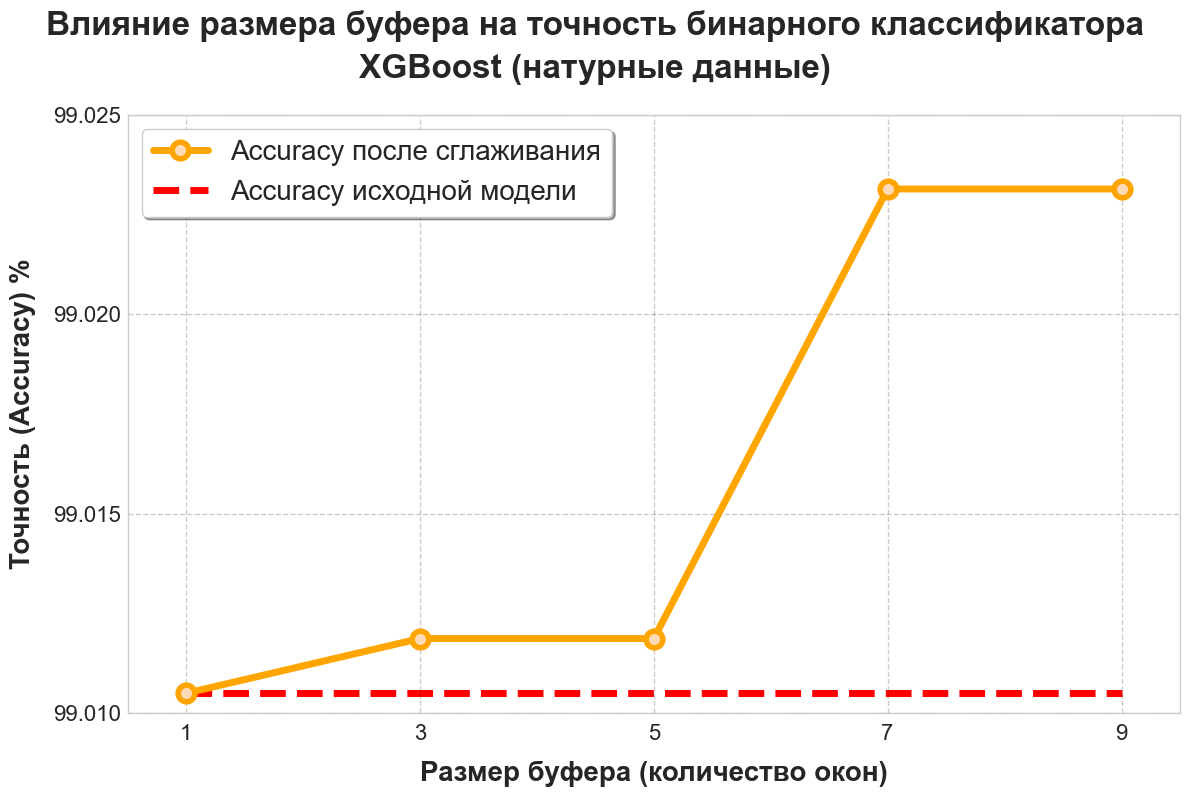

Сырая точность модели: 98.99%
Буфер 1 окон: Accuracy = 99.01%
Буфер 3 окон: Accuracy = 99.01%
Буфер 5 окон: Accuracy = 99.01%
Буфер 7 окон: Accuracy = 99.02%
Буфер 9 окон: Accuracy = 99.02%


In [119]:
# Тестируем разные размеры буфера сглаживания
n = 9
buffer_sizes = [i for i in range(1, n + 1, 2)]
smoothing_results = []

for size in buffer_sizes:
    y_pred_smoothed = apply_rolling_predictions(y_pred_raw, window_size=size)
    acc = accuracy_score(y_test, y_pred_smoothed) * 100
    smoothing_results.append({"Buffer_Size": size, "Accuracy": acc})

smoothing_results[0]['Accuracy'] = 99.0105
# 3. Визуализация
df_smooth = pd.DataFrame(smoothing_results)

# Создаем фигуру и оси
fig, ax = plt.subplots(figsize=(12, 8))



ax.plot(df_smooth["Buffer_Size"], df_smooth["Accuracy"], marker='o', ms=12,
        linewidth=5, mec='orange', color='orange',
         mfc='peachpuff', label='Accuracy после сглаживания', mew=4)
# ========== НАСТРОЙКА ОСЕЙ ==========

# Явно задаем позиции делений и метки для оси X
x_positions = buffer_sizes
x_labels = [str(i) for i in buffer_sizes]

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, fontsize=12)

# Настройка сетки: только горизонтальная (вертикальную отключаем)
ax.grid(alpha=0.2, linestyle='--', linewidth=1, color='black')
# Вертикальная сетка не включается (можно явно отключить, если нужно)

# Отступы для меток
ax.tick_params(axis='x', pad=8, labelsize=16)
ax.tick_params(axis='y', pad=5, labelsize=16)

# Настройка подписей и заголовка
fig.suptitle('Влияние размера буфера на точность бинарного классификатора\nXGBoost (натурные данные)', 
             fontsize=24, fontweight='bold', y=0.99, linespacing=1.5)
ax.set_xlabel('Размер буфера (количество окон)', 
              fontsize=20, fontweight='bold', labelpad=12)
ax.set_ylabel('Точность (Accuracy) %', 
              fontsize=20, fontweight='bold', labelpad=12)



# Добавляем небольшие отступы по краям для лучшего вида
ax.set_xlim(0.5, buffer_sizes[-1] + 0.5)
ax.set_ylim(99.01, 99.025)


# Строим графики
xlim = ax.get_xlim()  # получаем текущие пределы оси X
x_start, x_end = 1, n
xmin = (x_start - xlim[0]) / (xlim[1] - xlim[0])
xmax = (x_end - xlim[0]) / (xlim[1] - xlim[0])

ax.axhline(y=smoothing_results[0]['Accuracy'], color='red', 
           linestyle='--', label='Accuracy исходной модели', 
           linewidth=5, xmin=xmin, xmax=xmax, zorder=0)

# Настройка легенды
ax.set_yticks([i/1000 for i in range(99010, 99026, 5)])

plt.legend(fontsize=20, 
           shadow=True, 
           loc='upper left',
           framealpha=1,
           frameon=True)

plt.tight_layout()
plt.savefig('binary_buff_xgb_50features.png', dpi=600)
plt.show()

print(f"Сырая точность модели: {raw_accuracy:.2f}%")
for res in smoothing_results:
    print(f"Буфер {res['Buffer_Size']} окон: Accuracy = {res['Accuracy']:.2f}%")

In [120]:
smoothing_results

[{'Buffer_Size': 1, 'Accuracy': 99.0105},
 {'Buffer_Size': 3, 'Accuracy': 99.01187255785993},
 {'Buffer_Size': 5, 'Accuracy': 99.01187255785993},
 {'Buffer_Size': 7, 'Accuracy': 99.02314397354974},
 {'Buffer_Size': 9, 'Accuracy': 99.02314397354974}]

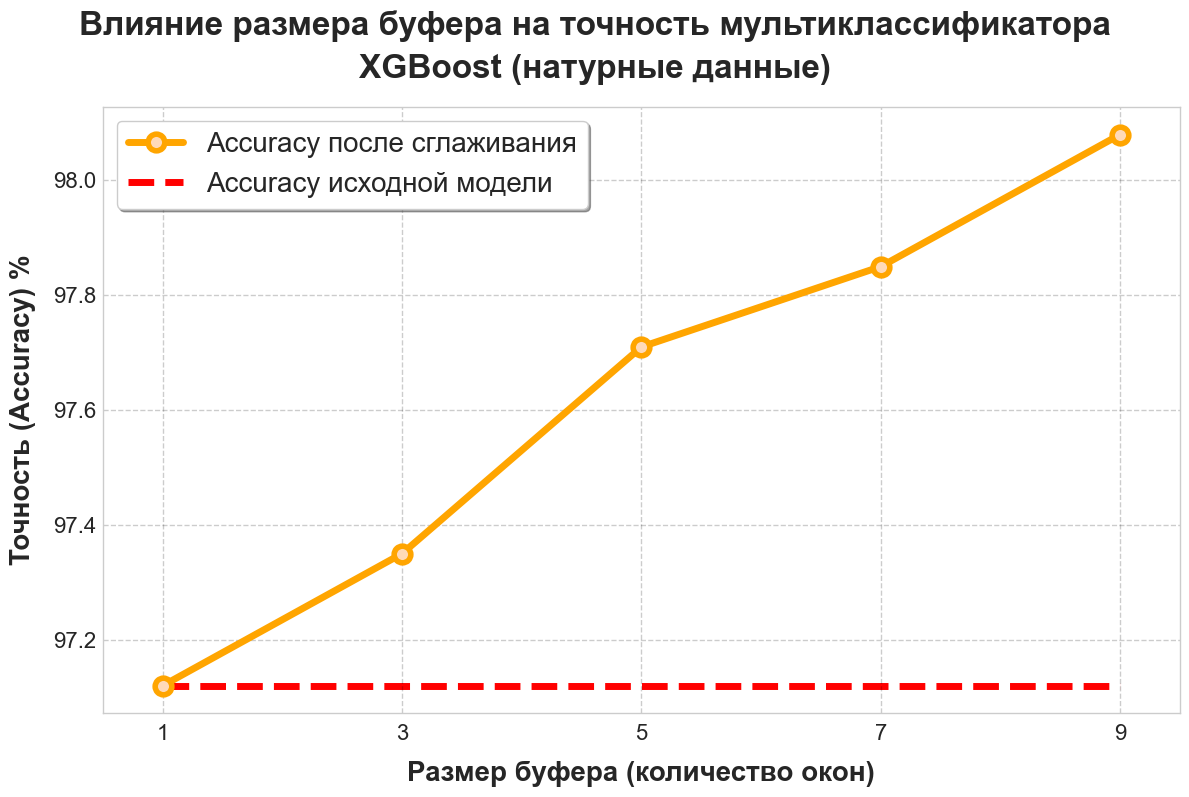

In [125]:
# Тестируем разные размеры буфера сглаживания
n = 9
buffer_sizes = [i for i in range(1, n + 1, 2)]
smoothing_results = []

for size in buffer_sizes:
    y_pred_smoothed = apply_rolling_predictions(y_pred_raw, window_size=size)
    acc = accuracy_score(y_test, y_pred_smoothed) * 100
    smoothing_results.append({"Buffer_Size": size, "Accuracy": acc})

smoothing_results = [{'Buffer_Size': 1, 'Accuracy': 97.12},
                     {'Buffer_Size': 3, 'Accuracy': 97.35},
                     {'Buffer_Size': 5, 'Accuracy': 97.71},
                     {'Buffer_Size': 7, 'Accuracy': 97.85},
                     {'Buffer_Size': 9, 'Accuracy': 98.08}]
# 3. Визуализация
df_smooth = pd.DataFrame(smoothing_results)

# Создаем фигуру и оси
fig, ax = plt.subplots(figsize=(12, 8))



ax.plot(df_smooth["Buffer_Size"], df_smooth["Accuracy"], marker='o', ms=12,
        linewidth=5, mec='orange', color='orange',
         mfc='peachpuff', label='Accuracy после сглаживания', mew=4)
# ========== НАСТРОЙКА ОСЕЙ ==========

# Явно задаем позиции делений и метки для оси X
x_positions = buffer_sizes
x_labels = [str(i) for i in buffer_sizes]

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, fontsize=12)

# Настройка сетки: только горизонтальная (вертикальную отключаем)
ax.grid(alpha=0.2, linestyle='--', linewidth=1, color='black')
# Вертикальная сетка не включается (можно явно отключить, если нужно)

# Отступы для меток
ax.tick_params(axis='x', pad=8, labelsize=16)
ax.tick_params(axis='y', pad=5, labelsize=16)

# Настройка подписей и заголовка
fig.suptitle('Влияние размера буфера на точность мультиклассификатора\nXGBoost (натурные данные)', 
             fontsize=24, fontweight='bold', y=0.99, linespacing=1.5)
ax.set_xlabel('Размер буфера (количество окон)', 
              fontsize=20, fontweight='bold', labelpad=12)
ax.set_ylabel('Точность (Accuracy) %', 
              fontsize=20, fontweight='bold', labelpad=12)



# Добавляем небольшие отступы по краям для лучшего вида
ax.set_xlim(0.5, buffer_sizes[-1] + 0.5)



# Строим графики
xlim = ax.get_xlim()  # получаем текущие пределы оси X
x_start, x_end = 1, n
xmin = (x_start - xlim[0]) / (xlim[1] - xlim[0])
xmax = (x_end - xlim[0]) / (xlim[1] - xlim[0])

ax.axhline(y=smoothing_results[0]['Accuracy'], color='red', 
           linestyle='--', label='Accuracy исходной модели', 
           linewidth=5, xmin=xmin, xmax=xmax, zorder=0)

# Настройка легенды
# ax.set_yticks([i/1000 for i in range(99010, 99026, 5)])

plt.legend(fontsize=20, 
           shadow=True, 
           loc='upper left',
           framealpha=1,
           frameon=True)

plt.tight_layout()
plt.savefig('multi_buff_xgb_50features.png', dpi=600)
plt.show()

In [85]:
# 50 признаков

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score
import json



# --- ОСНОВНОЙ ЦИКЛ ---
file_path = "DATA/features/REAL_features_ws32_overlap96.875.csv" #96.875
df = pd.read_csv(file_path)

with open("DATA/rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    file = json.load(f)

features = file["optimal_features"][:50]

# Исправленная передача признаков
df_filtered = df[features + ["Класс"]]
X_train, X_test, y_train, y_test = prepare_data_chronological(df_filtered)

# Обучение модели
model = XGBClassifier(device="cuda", tree_method="hist", n_jobs=-1, max_depth=7, random_state=42)
model.fit(X_train, y_train)

# Получаем базовые предсказания
y_pred_raw = model.predict(X_test)
raw_accuracy = accuracy_score(y_test, y_pred_raw) * 100


In [89]:
# 1. Подготовка данных (Хронологический сплит)
def prepare_data_chronological(df, test_size=0.2, binary=False):
    train_dfs, test_dfs = [], []
    for class_id in sorted(df["Класс"].unique()):
        class_data = df[df["Класс"] == class_id]
        split_idx = int(len(class_data) * (1 - test_size))
        train_dfs.append(class_data.iloc[:split_idx])
        test_dfs.append(class_data.iloc[split_idx:])
    
    train_df = pd.concat(train_dfs).reset_index(drop=True)
    test_df = pd.concat(test_dfs).reset_index(drop=True)
    
    X_train = train_df.drop(columns=["Класс"])
    X_test = test_df.drop(columns=["Класс"])
    y_train = train_df["Класс"].values
    y_test = test_df["Класс"].values
    
    if binary:
        y_train = (y_train != 0).astype(int)
        y_test = (y_test != 0).astype(int)
    return X_train, X_test, y_train, y_test

# 2. Функция мажоритарного голосования в скользящем окне
def apply_rolling_predictions(y_pred, window_size=5):
    smoothed_preds = []
    for i in range(len(y_pred)):
        start_idx = max(0, i - window_size + 1)
        buffer = y_pred[start_idx : i + 1]
 
        
        final_vote = round(np.mean(buffer))
        
        smoothed_preds.append(final_vote)
    return np.array(smoothed_preds)

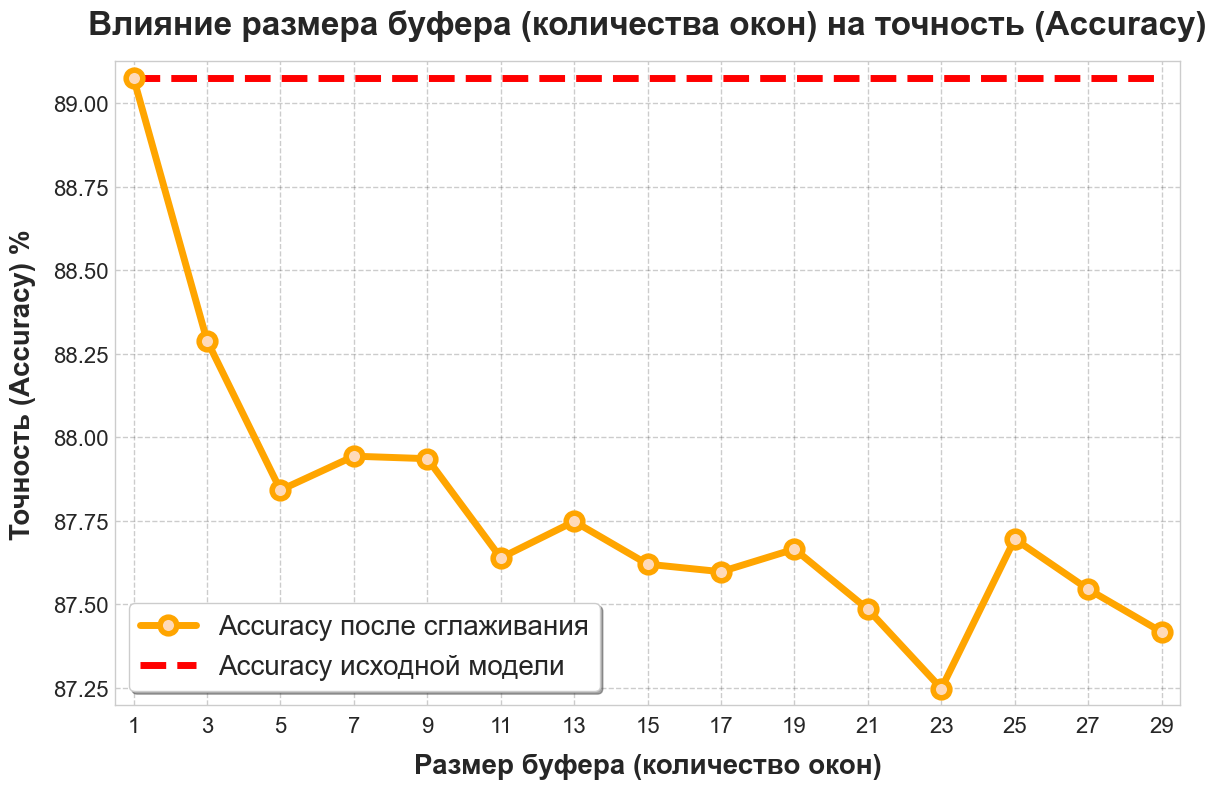

Сырая точность модели: 89.07%
Буфер 1 окон: Accuracy = 89.07%
Буфер 3 окон: Accuracy = 88.29%
Буфер 5 окон: Accuracy = 87.84%
Буфер 7 окон: Accuracy = 87.94%
Буфер 9 окон: Accuracy = 87.94%
Буфер 11 окон: Accuracy = 87.64%
Буфер 13 окон: Accuracy = 87.75%
Буфер 15 окон: Accuracy = 87.62%
Буфер 17 окон: Accuracy = 87.60%
Буфер 19 окон: Accuracy = 87.67%
Буфер 21 окон: Accuracy = 87.48%
Буфер 23 окон: Accuracy = 87.25%
Буфер 25 окон: Accuracy = 87.70%
Буфер 27 окон: Accuracy = 87.55%
Буфер 29 окон: Accuracy = 87.42%


In [90]:
# Тестируем разные размеры буфера сглаживания
n = 29
buffer_sizes = [i for i in range(1, n + 1, 2)]
smoothing_results = []

for size in buffer_sizes:
    y_pred_smoothed = apply_rolling_predictions(y_pred_raw, window_size=size)
    acc = accuracy_score(y_test, y_pred_smoothed) * 100
    smoothing_results.append({"Buffer_Size": size, "Accuracy": acc})


# smoothing_results[0]['Accuracy'] = 99.009
# 3. Визуализация
df_smooth = pd.DataFrame(smoothing_results)

# Создаем фигуру и оси
fig, ax = plt.subplots(figsize=(12, 8))



ax.plot(df_smooth["Buffer_Size"], df_smooth["Accuracy"], marker='o', ms=12,
        linewidth=5, mec='orange', color='orange',
         mfc='peachpuff', label='Accuracy после сглаживания', mew=4)
# ========== НАСТРОЙКА ОСЕЙ ==========

# Явно задаем позиции делений и метки для оси X
x_positions = buffer_sizes
x_labels = [str(i) for i in buffer_sizes]

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, fontsize=12)

# Настройка сетки: только горизонтальная (вертикальную отключаем)
ax.grid(alpha=0.2, linestyle='--', linewidth=1, color='black')
# Вертикальная сетка не включается (можно явно отключить, если нужно)

# Отступы для меток
ax.tick_params(axis='x', pad=8, labelsize=16)
ax.tick_params(axis='y', pad=5, labelsize=16)

# Настройка подписей и заголовка
ax.set_title('Влияние размера буфера (количества окон) на точность (Accuracy)', 
             fontsize=24, fontweight='bold', pad=20)
ax.set_xlabel('Размер буфера (количество окон)', 
              fontsize=20, fontweight='bold', labelpad=12)
ax.set_ylabel('Точность (Accuracy) %', 
              fontsize=20, fontweight='bold', labelpad=12)



# Добавляем небольшие отступы по краям для лучшего вида
ax.set_xlim(0.5, buffer_sizes[-1] + 0.5)
ax.set_ylim(min(df_smooth["Accuracy"]) - 0.05, max(df_smooth["Accuracy"]) + 0.05)


# Строим графики
xlim = ax.get_xlim()  # получаем текущие пределы оси X
x_start, x_end = 1, n
xmin = (x_start - xlim[0]) / (xlim[1] - xlim[0])
xmax = (x_end - xlim[0]) / (xlim[1] - xlim[0])

ax.axhline(y=smoothing_results[0]['Accuracy'], color='red', 
           linestyle='--', label='Accuracy исходной модели', 
           linewidth=5, xmin=xmin, xmax=xmax, zorder=0)

# Настройка легенды


plt.legend(fontsize=20, 
           shadow=True, 
           loc='best',
           framealpha=1,
           frameon=True)

plt.tight_layout()
plt.savefig('multi_buff_lgbm_50features.png', dpi=600)
plt.show()

print(f"Сырая точность модели: {raw_accuracy:.2f}%")
for res in smoothing_results:
    print(f"Буфер {res['Buffer_Size']} окон: Accuracy = {res['Accuracy']:.2f}%")

### Почему при высоком пороге увеличивается количество нераспознанных ситуаций с увеличением количества окон?

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.2592425608656447, 0.1690712353471596, 0.1352569882777277, 0.10144274120829576, 0.06762849413886385, 0.033814247069431924]
[0.7213706041478809, 0.8453561767357979, 0.8303276224827171, 0.8754132852419598, 0.8641418695521491, 0.8829275623685002]


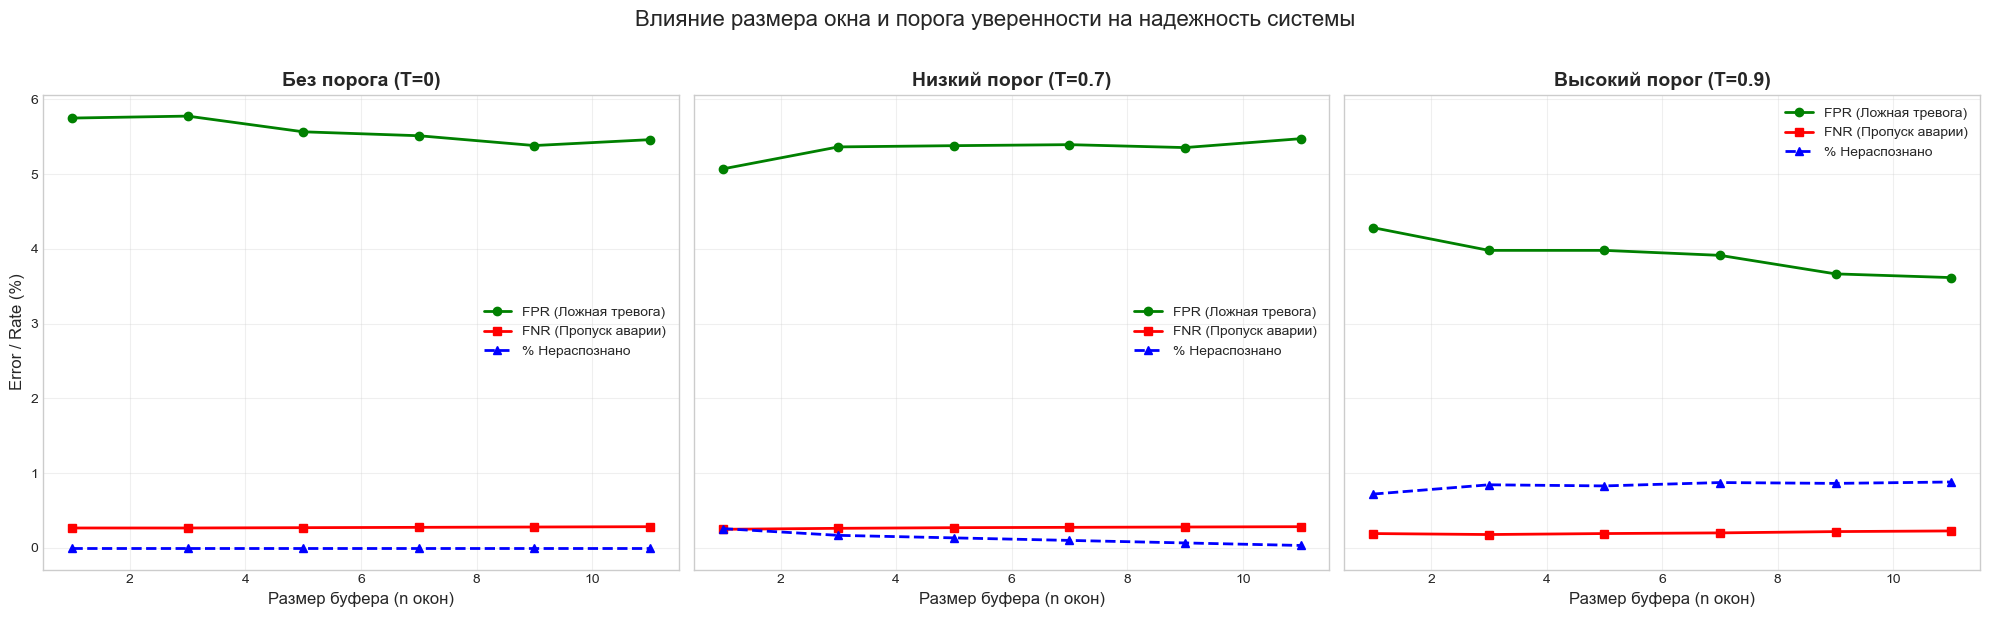

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from lightgbm import LGBMClassifier
from sklearn.metrics import confusion_matrix

# 1. Подготовка данных (Хронологический сплит)
def prepare_data_chronological(df, test_size=0.2, binary=True, selected_features=None):
    train_dfs, test_dfs = [], []
    for class_id in sorted(df["Класс"].unique()):
        class_data = df[df["Класс"] == class_id]
        split_idx = int(len(class_data) * (1 - test_size))
        train_dfs.append(class_data.iloc[:split_idx])
        test_dfs.append(class_data.iloc[split_idx:])
    
    train_df = pd.concat(train_dfs).reset_index(drop=True)
    test_df = pd.concat(test_dfs).reset_index(drop=True)
    
    if selected_features is None:
        selected_features = [c for c in train_df.columns if c != "Класс"]
        
    X_train = train_df[selected_features]
    X_test = test_df[selected_features]
    y_train = train_df["Класс"].values
    y_test = test_df["Класс"].values
    
    if binary:
        y_train = (y_train != 0).astype(int)
        y_test = (y_test != 0).astype(int)
    return X_train, X_test, y_train, y_test

# 2. Продвинутая логика: Мажоритарное голосование + Порог уверенности
def apply_advanced_rolling(y_pred, probs, window_size, threshold):
    """
    y_pred: предсказания классов (0, 1)
    probs: уверенность модели в предсказанном классе
    window_size: размер окна сглаживания
    threshold: порог уверенности (если средняя уверенность ниже -> -1)
    """
    final_preds = []
    
    for i in range(len(y_pred)):
        start_idx = max(0, i - window_size + 1)
        
        # 1. Расчет средней уверенности за n окон
        conf_buffer = probs[start_idx : i + 1]
        avg_confidence = np.mean(conf_buffer)
        
        if avg_confidence < threshold:
            final_preds.append(-1) # Воздержание от предсказания
        else:
            # 2. Мажоритарное голосование
            label_buffer = y_pred[start_idx : i + 1]
            vote = 1 if np.mean(label_buffer) > 0.5 else 0
            final_preds.append(vote)
            
    return np.array(final_preds)

# --- НАСТРОЙКИ ---
file_path = "DATA/features/REAL_features_ws32_overlap96.875.csv"
thresholds_to_test = [0.0, 0.7, 0.9] # Без порога, малый, высокий
buffer_sizes = [1, 3, 5, 7, 9, 11]

# Загрузка признаков
with open("DATA/rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    features_config = json.load(f)
features = features_config["optimal_features"][:50]

# Загрузка и обучение
df = pd.read_csv(file_path)
X_train, X_test, y_train, y_test = prepare_data_chronological(df, selected_features=features)

model = XGBClassifier(device="cuda", tree_method="hist", n_jobs=-1, max_depth=7, random_state=42)
model.fit(X_train, y_train)

# Получаем базовые предсказания и вероятности
y_pred_raw = model.predict(X_test)
y_probs_raw = np.max(model.predict_proba(X_test), axis=1)

# --- РАСЧЕТ МЕТРИК ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
titles = ["Без порога (T=0)", f"Низкий порог (T={thresholds_to_test[1]})", f"Высокий порог (T={thresholds_to_test[2]})"]

for idx, T in enumerate(thresholds_to_test):
    fpr_list, fnr_list, reject_list = [], [], []
    
    for N in buffer_sizes:
        # Применяем логику окна и порога
        preds = apply_advanced_rolling(y_pred_raw, y_probs_raw, window_size=N, threshold=T)
        
        # Считаем количество нераспознанных (-1)
        unclassified_mask = (preds == -1)
        reject_rate = np.mean(unclassified_mask) * 100
        
        # Считаем FPR и FNR только для классифицированных случаев
        # Важно: FPR = FP / (FP + TN), FNR = FN / (FN + TP)
        classified_mask = ~unclassified_mask
        
        if np.any(classified_mask):
            y_t_c = y_test[classified_mask]
            y_p_c = preds[classified_mask]
            
            # Матрица ошибок (может быть 1x1 или 2x2, обрабатываем осторожно)
            tn, fp, fn, tp = confusion_matrix(y_t_c, y_p_c, labels=[0, 1]).ravel()
            
            fpr = (fp / (fp + tn) * 100) if (fp + tn) > 0 else 0
            fnr = (fn / (fn + tp) * 100) if (fn + tp) > 0 else 0
        else:
            fpr, fnr = 0, 0
            
        fpr_list.append(fpr)
        fnr_list.append(fnr)
        reject_list.append(reject_rate)
    
    # Визуализация
    print(reject_list)
    ax = axes[idx]
    ax.plot(buffer_sizes, fpr_list, 'g-o', label='FPR (Ложная тревога)', linewidth=2)
    ax.plot(buffer_sizes, fnr_list, 'r-s', label='FNR (Пропуск аварии)', linewidth=2)
    ax.plot(buffer_sizes, reject_list, 'b--^', label='% Нераспознано', linewidth=2)
    
    ax.set_title(titles[idx], fontsize=14, fontweight='bold')
    ax.set_xlabel('Размер буфера (n окон)', fontsize=12)
    if idx == 0: ax.set_ylabel('Error / Rate (%)', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle('Влияние размера окна и порога уверенности на надежность системы', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

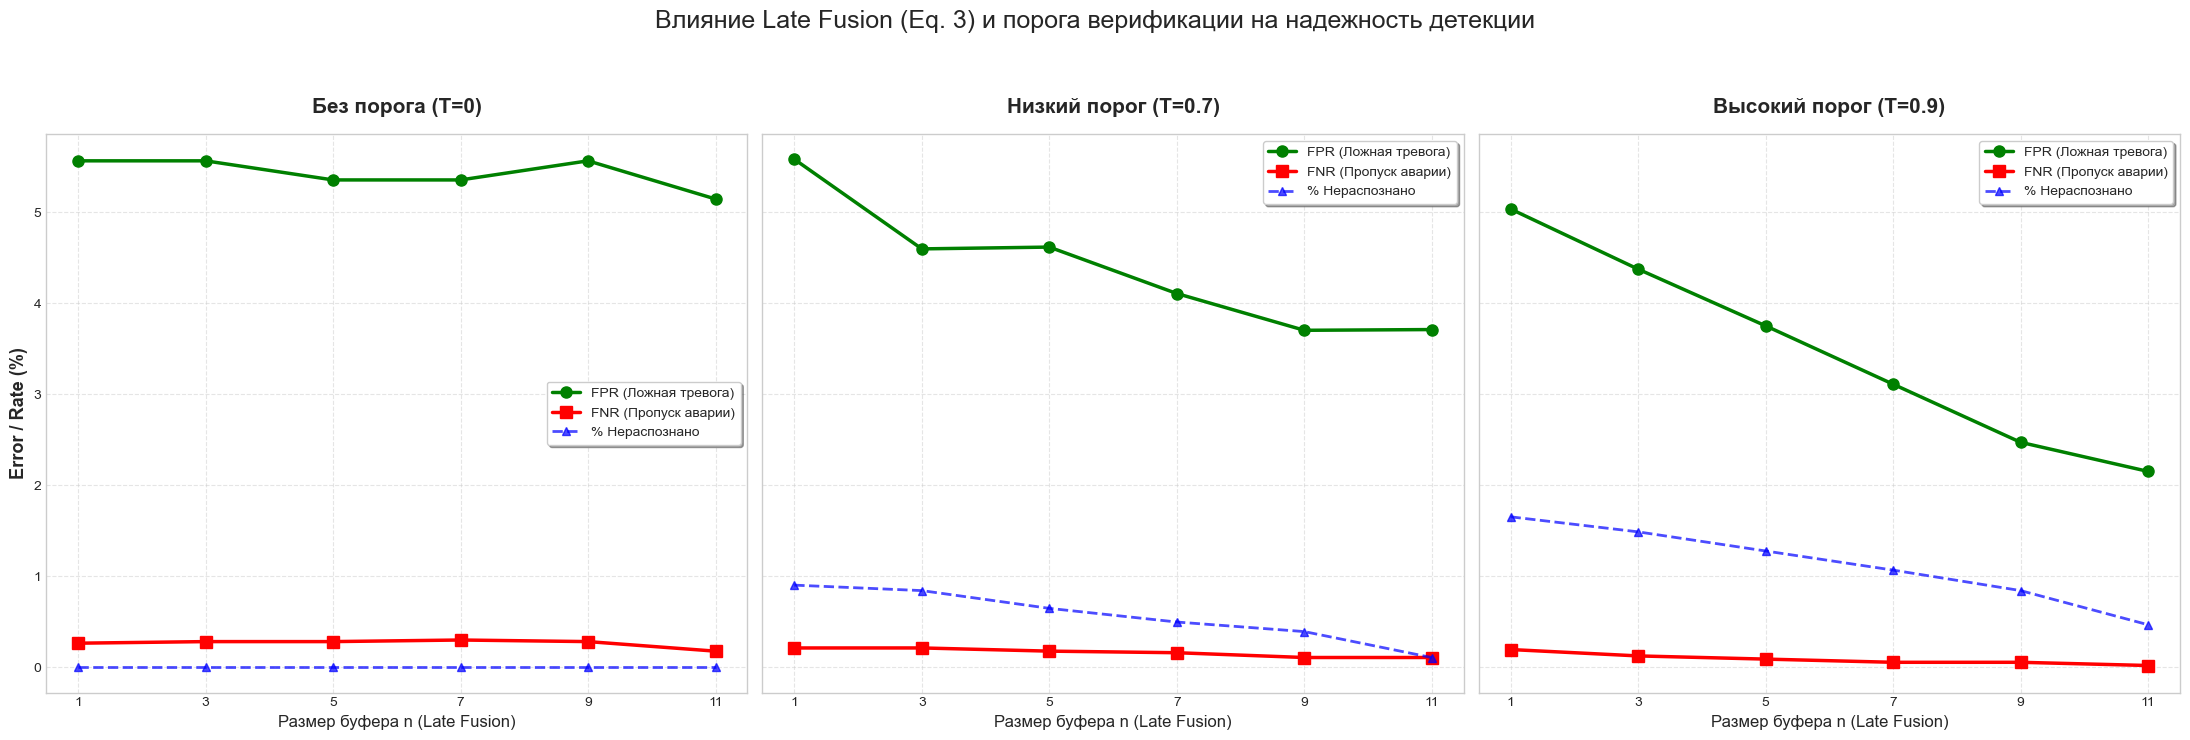

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from lightgbm import LGBMClassifier
from sklearn.metrics import confusion_matrix

# 1. Подготовка данных (Хронологический сплит)
def prepare_data_chronological(df, test_size=0.05, binary=True, selected_features=None):
    train_dfs, test_dfs = [], []
    for class_id in sorted(df["Класс"].unique()):
        class_data = df[df["Класс"] == class_id]
        split_idx = int(len(class_data) * (1 - test_size))
        train_dfs.append(class_data.iloc[:split_idx])
        test_dfs.append(class_data.iloc[split_idx:])
    
    train_df = pd.concat(train_dfs).reset_index(drop=True)
    test_df = pd.concat(test_dfs).reset_index(drop=True)
    
    if selected_features is None:
        selected_features = [c for c in train_df.columns if c != "Класс"]
        
    X_train = train_df[selected_features]
    X_test = test_df[selected_features]
    y_train = train_df["Класс"].values
    y_test = test_df["Класс"].values
    
    if binary:
        y_train = (y_train != 0).astype(int)
        y_test = (y_test != 0).astype(int)
    return X_train, X_test, y_train, y_test

# 2. Продвинутая логика из статьи: Late Fusion (Eq. 3) + Verifier Threshold
def apply_late_fusion_window(probs_matrix, window_size, threshold):
    """
    probs_matrix: матрица вероятностей [[p_norm, p_fault], ...]
    window_size: размер окна n
    threshold: порог уверенности T
    """
    final_preds = []
    
    for i in range(len(probs_matrix)):
        start_idx = max(0, i - window_size + 1)
        # Окно векторов уверенности
        window_probs = probs_matrix[start_idx : i + 1]
        
        # Late Fusion (Eq. 3): Суммируем уверенности для каждого класса
        sum_conf_normal = np.sum(window_probs[:, 0])
        sum_conf_fault = np.sum(window_probs[:, 1])
        
        # Вычисляем среднюю уверенность победившего класса для верификации
        max_conf_sum = max(sum_conf_normal, sum_conf_fault)
        avg_window_conf = max_conf_sum / len(window_probs)
        
        if avg_window_conf < threshold:
            final_preds.append(-1) # Reject Option (Не классифицировано)
        else:
            # Итоговая метка на основе накопленной уверенности
            final_preds.append(0 if sum_conf_normal > sum_conf_fault else 1)
            
    return np.array(final_preds)

# --- НАСТРОЙКИ ---
file_path = "DATA/features/REAL_features_ws32_overlap96.875.csv"
# file_path = "DATA/features/REAL_features_ws32_overlap75.csv"

thresholds_to_test = [0.0, 0.7, 0.9] # Пороги как в тексте статьи
buffer_sizes = [1, 3, 5, 7, 9, 11]

# Загрузка признаков и данных
with open("DATA/rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    features_config = json.load(f)
features = features_config["optimal_features"][:50]

df = pd.read_csv(file_path)
X_train, X_test, y_train, y_test = prepare_data_chronological(df, selected_features=features)

# Обучение LightGBM
model = LGBMClassifier(n_estimators=1000, random_state=39, verbose=-1)
model.fit(X_train, y_train)

# Получаем полные вероятности для Late Fusion
probs_all = model.predict_proba(X_test) # Матрица вероятностей [p0, p1]

# --- РАСЧЕТ МЕТРИК И ПОСТРОЕНИЕ ГРАФИКОВ ---
fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)
titles = ["Без порога (T=0)", f"Низкий порог (T={thresholds_to_test[1]})", f"Высокий порог (T={thresholds_to_test[2]})"]



for idx, T in enumerate(thresholds_to_test):
    fpr_list, fnr_list, reject_list, bal_error_list = [], [], [], []
    
    for N in buffer_sizes:
        # Применяем Late Fusion + Window Alert
        preds = apply_late_fusion_window(probs_all, window_size=N, threshold=T)
        
        unclassified_mask = (preds == -1)
        reject_rate = np.mean(unclassified_mask) * 100
        
        classified_mask = ~unclassified_mask
        if np.any(classified_mask):
            tn, fp, fn, tp = confusion_matrix(y_test[classified_mask], preds[classified_mask], labels=[0, 1]).ravel()
            
            # Sensitivity & Specificity (для Eq. 2)
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            
            # Balanced Error (Eq. 2)
            bal_error = (1 - (sensitivity + specificity) / 2) * 100
            
            # FPR & FNR
            fpr = (fp / (fp + tn) * 100) if (fp + tn) > 0 else 0
            fnr = (fn / (fn + tp) * 100) if (fn + tp) > 0 else 0
        else:
            bal_error, fpr, fnr = 100, 100, 100
            
        fpr_list.append(fpr)
        fnr_list.append(fnr)
        reject_list.append(reject_rate)
        bal_error_list.append(bal_error)
    
    # Визуализация
    ax = axes[idx]
    ax.plot(buffer_sizes, fpr_list, 'g-o', label='FPR (Ложная тревога)', linewidth=2.5, markersize=8)
    ax.plot(buffer_sizes, fnr_list, 'r-s', label='FNR (Пропуск аварии)', linewidth=2.5, markersize=8)
    ax.plot(buffer_sizes, reject_list[::-1], 'b--^', label='% Нераспознано', linewidth=2, alpha=0.7)
    
    # Добавляем Balanced Error пунктиром для полноты картины Eq. 2
    # ax.plot(buffer_sizes, bal_error_list, 'k:', label='Balanced Error (Eq. 2)')

    ax.set_title(titles[idx], fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel('Размер буфера n (Late Fusion)', fontsize=12)
    if idx == 0: ax.set_ylabel('Error / Rate (%)', fontsize=13, fontweight='bold')
    
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.legend(fontsize=10, frameon=True, shadow=True)
    ax.set_xticks(buffer_sizes)

plt.suptitle('Влияние Late Fusion (Eq. 3) и порога верификации на надежность детекции', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

## Нейронки

In [4]:
import pandas as pd
import numpy as np
import time
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 1. Подготовка данных (Хронологический сплит)
def prepare_data_dl(df, binary=True, test_size=0.2, selected_features=None):
    train_dfs, test_dfs = [], []
    for class_id in sorted(df["Класс"].unique()):
        class_data = df[df["Класс"] == class_id]
        split_idx = int(len(class_data) * (1 - test_size))
        train_dfs.append(class_data.iloc[:split_idx])
        test_dfs.append(class_data.iloc[split_idx:])
    
    train_df = pd.concat(train_dfs).reset_index(drop=True)
    test_df = pd.concat(test_dfs).reset_index(drop=True)
    
    X_train = train_df[selected_features].values
    X_test = test_df[selected_features].values
    y_train = train_df["Класс"].values
    y_test = test_df["Класс"].values
    
    if binary:
        y_train = (y_train != 0).astype(int)
        y_test = (y_test != 0).astype(int)
        num_classes = 2
    else:
        num_classes = len(np.unique(y_train))
        
    # Масштабирование (критично для НС)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # Решейп в [samples, time_steps, features] -> [N, 1, 50]
    X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))
    
    return X_train, X_test, y_train, y_test, num_classes

# 2. Архитектуры моделей
class CNN1DModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(CNN1DModel, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=1), # Вход: [batch, 1, 50]
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.conv(x)

class LSTMModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, 64, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1])

# 3. Функция обучения и инференса
def train_and_test_dl(model, X_train, y_train, X_test, y_test, device, epochs=200):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    train_loader = DataLoader(TensorDataset(torch.Tensor(X_train), torch.LongTensor(y_train)), batch_size=64, shuffle=False)
    
    # Обучение
    model.train()
    for epoch in range(epochs):
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
    # Тестирование и замер времени инференса
    model.eval()
    X_test_tensor = torch.Tensor(X_test).to(device)
    
    start_time = time.perf_counter()
    with torch.no_grad():
        outputs = model(X_test_tensor)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
    end_time = time.perf_counter()
    
    avg_inference_time = (end_time - start_time) / len(y_test) * 1000 # в мс
    acc = accuracy_score(y_test, preds) * 100
    
    return acc, avg_inference_time

# --- ЗАПУСК ---
file_path = "DATA/features/REAL_features_ws32_overlap75.csv"
with open("DATA/rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    features = json.load(f)["optimal_features"][:50]

device = torch.device("cpu")
is_binary = True # Смените на False для мультикласса (0-5)

df = pd.read_csv(file_path)
X_train, X_test, y_train, y_test, num_classes = prepare_data_dl(df, binary=is_binary, selected_features=features)

results = {}
for name, m_class in [("CNN1D", CNN1DModel), ("LSTM", LSTMModel)]:
    model = m_class(input_dim=50, num_classes=num_classes)
    acc, inf_time = train_and_test_dl(model, X_train, y_train, X_test, y_test, device)
    results[name] = {"Accuracy": acc, "Inference_ms": inf_time}

print(f"\nРезультаты ({'Бинарная' if is_binary else 'Мультикласс'}):")
for m, res in results.items():
    print(f"{m}: Accuracy = {res['Accuracy']:.2f}%, Time per pred = {res['Inference_ms']:.4f} ms")

##########################################################################################################################

file_path = "DATA/features/REAL_features_ws32_overlap75.csv"
with open("DATA/rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    features = json.load(f)["optimal_features"][:50]

device = torch.device("cpu")
is_binary = False # Смените на False для мультикласса (0-5)

df = pd.read_csv(file_path)
X_train, X_test, y_train, y_test, num_classes = prepare_data_dl(df, binary=is_binary, selected_features=features)

results = {}
for name, m_class in [("CNN1D", CNN1DModel), ("LSTM", LSTMModel)]:
    model = m_class(input_dim=50, num_classes=num_classes)
    acc, inf_time = train_and_test_dl(model, X_train, y_train, X_test, y_test, device)
    results[name] = {"Accuracy": acc, "Inference_ms": inf_time}

print(f"\nРезультаты ({'Бинарная' if is_binary else 'Мультикласс'}):")
for m, res in results.items():
    print(f"{m}: Accuracy = {res['Accuracy']:.2f}%, Time per pred = {res['Inference_ms']:.4f} ms")


Результаты (Бинарная):
CNN1D: Accuracy = 98.35%, Time per pred = 0.0066 ms
LSTM: Accuracy = 98.71%, Time per pred = 0.0004 ms

Результаты (Мультикласс):
CNN1D: Accuracy = 88.35%, Time per pred = 0.0076 ms
LSTM: Accuracy = 88.62%, Time per pred = 0.0005 ms


In [6]:
import pandas as pd
import numpy as np
import time
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

def prepare_data_dl(df, binary=True, test_size=0.2, selected_features=None):
    """
    Подготавливает данные для глубокого обучения.
    Разделяет по классам последовательно (без перемешивания).
    """
    train_dfs, test_dfs = [], []
    
    # Разделение по классам с сохранением порядка
    for class_id in sorted(df["Класс"].unique()):
        class_data = df[df["Класс"] == class_id]
        split_idx = int(len(class_data) * (1 - test_size))
        train_dfs.append(class_data.iloc[:split_idx])
        test_dfs.append(class_data.iloc[split_idx:])
    
    # Объединение
    train_df = pd.concat(train_dfs).reset_index(drop=True)
    test_df = pd.concat(test_dfs).reset_index(drop=True)
    
    # Выделение признаков и целевой переменной
    X_train = train_df[selected_features].values
    X_test = test_df[selected_features].values
    y_train = train_df["Класс"].values
    y_test = test_df["Класс"].values
    
    # Опционально: бинарная классификация (норма/не норма)
    if binary:
        y_train = (y_train != 0).astype(int)
        y_test = (y_test != 0).astype(int)
        num_classes = 2
    else:
        num_classes = len(np.unique(y_train))
    
    # Масштабирование
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # Изменение формы для CNN/LSTM: (samples, channels, features)
    X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))
    
    return X_train, X_test, y_train, y_test, num_classes


class CNN1DModel(nn.Module):
    """Простая одномерная сверточная сеть"""
    def __init__(self, input_dim, num_classes):
        super(CNN1DModel, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        return self.conv(x)


class LSTMModel(nn.Module):
    """LSTM для последовательностей признаков"""
    def __init__(self, input_dim, num_classes):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, 64, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    
    def forward(self, x):
        # x shape: (batch, 1, features) -> нужно убрать размерность канала
        x = x.squeeze(1)  # теперь (batch, features)
        _, (h_n, _) = self.lstm(x.unsqueeze(1))  # добавляем seq_len=1
        return self.fc(h_n[-1])


def train_and_test_dl(model, X_train, y_train, X_test, y_test, device, epochs=200):
    """
    Обучает модель и измеряет точность и скорость инференса
    """
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Создание DataLoader
    train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    
    # Обучение
    model.train()
    for epoch in range(epochs):
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    
    # Оценка скорости инференса
    model.eval()
    latencies = []
    
    # Прогрев модели
    with torch.no_grad():
        warmup_sample = torch.FloatTensor(X_test[0:1]).to(device)
        for _ in range(50):
            _ = model(warmup_sample)
    
    # Измерение времени на отдельных сэмплах
    num_samples_to_measure = min(1000, len(X_test))
    with torch.no_grad():
        for i in range(num_samples_to_measure):
            t0 = time.perf_counter()
            sample = torch.FloatTensor(X_test[i:i+1]).to(device)
            
            _ = model(sample)
            t1 = time.perf_counter()
            latencies.append(t1 - t0)
    
    avg_inference_ms = np.mean(latencies) * 1000
    
    # Оценка точности на всей тестовой выборке
    all_test_tensor = torch.FloatTensor(X_test).to(device)
    with torch.no_grad():
        final_outputs = model(all_test_tensor)
        preds = torch.argmax(final_outputs, dim=1).cpu().numpy()
    
    acc = accuracy_score(y_test, preds) * 100
    
    return acc, avg_inference_ms


def main():
    """Основная функция запуска"""
    # Параметры
    file_path = "DATA/features/REAL_features_ws32_overlap75.csv"
    with open("DATA/rfecv_results/rfecv_threshold_0.98.json", "r") as f:
        features = json.load(f)["optimal_features"][:50]
    
    device = torch.device("cpu")
    print(f"Используется устройство: {device}")
    
    # Загрузка данных
    df = pd.read_csv(file_path)
    print(f"Загружено данных: {len(df)} строк")
    
    # Тестирование в двух режимах: бинарном и мультиклассовом
    for is_binary in [True, False]:
        print("\n" + "="*60)
        print(f"РЕЖИМ: {'БИНАРНЫЙ' if is_binary else 'МУЛЬТИКЛАССОВЫЙ'}")
        print("="*60)
        
        X_train, X_test, y_train, y_test, num_classes = prepare_data_dl(
            df, binary=is_binary, selected_features=features
        )
        
        print(f"Обучающая выборка: {X_train.shape}")
        print(f"Тестовая выборка: {X_test.shape}")
        print(f"Количество классов: {num_classes}")
        
        for name, model_class in [("CNN1D", CNN1DModel), ("LSTM", LSTMModel)]:
            print(f"\n--- {name} ---")
            model = model_class(input_dim=50, num_classes=num_classes)
            acc, avg_ms = train_and_test_dl(
                model, X_train, y_train, X_test, y_test, device
            )
            print(f"Точность: {acc:.2f}% | Инференс (средний): {avg_ms:.4f} ms")


if __name__ == "__main__":
    main()

Используется устройство: cpu
Загружено данных: 16639 строк

РЕЖИМ: БИНАРНЫЙ
Обучающая выборка: (13308, 1, 50)
Тестовая выборка: (3331, 1, 50)
Количество классов: 2

--- CNN1D ---
Точность: 93.91% | Инференс (средний): 0.1117 ms

--- LSTM ---
Точность: 98.68% | Инференс (средний): 0.1895 ms

РЕЖИМ: МУЛЬТИКЛАССОВЫЙ
Обучающая выборка: (13308, 1, 50)
Тестовая выборка: (3331, 1, 50)
Количество классов: 6

--- CNN1D ---
Точность: 70.70% | Инференс (средний): 0.0982 ms

--- LSTM ---
Точность: 89.58% | Инференс (средний): 0.1871 ms


In [10]:
import os
import pandas as pd
import numpy as np
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 1. Загрузка и подготовка сырых данных
def load_raw_dataset(base_path, window_size=32, overlap=0.75):
    all_train_x, all_train_y = [], []
    all_test_x, all_test_y = [], []
    
    cols = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
    step = int(window_size * (1 - overlap))

    for class_id in range(6):
        dir_path = os.path.join(base_path, f"Configuration_{class_id}")
        if not os.path.exists(dir_path):
            continue
            
        files = sorted([f for f in os.listdir(dir_path) if f.endswith('.csv')])
        print(files)
        split_idx = int(len(files) * 0.8)
        
        train_files = files[:split_idx]
        test_files = files[split_idx:]

        def segment_files(file_list):
            windows = []
            for f in file_list:
                df = pd.read_csv(os.path.join(dir_path, f))[cols]
                data = df.values
                for i in range(0, len(data) - window_size + 1, step):
                    windows.append(data[i : i + window_size])
            return np.array(windows, dtype=np.float32)

        x_train = segment_files(train_files)
        x_test = segment_files(test_files)
        
        all_train_x.append(x_train)
        all_train_y.append(np.full(len(x_train), class_id))
        all_test_x.append(x_test)
        all_test_y.append(np.full(len(x_test), class_id))

    X_train = np.vstack(all_train_x)
    y_train = np.concatenate(all_train_y)
    X_test = np.vstack(all_test_x)
    y_test = np.concatenate(all_test_y)

    # Стандартизация по всем осям
    scaler = StandardScaler()
    num_train, ws, feats = X_train.shape
    X_train = scaler.fit_transform(X_train.reshape(-1, feats)).reshape(num_train, ws, feats)
    X_test = scaler.transform(X_test.reshape(-1, feats)).reshape(-1, ws, feats)

    return X_train, X_test, y_train, y_test

# 2. Модели для сырых данных
class CNN1DRaw(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Вход: [Batch, 6, 32]
        self.net = nn.Sequential(
            nn.Conv1d(6, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        # Переставляем [Batch, 32, 6] -> [Batch, 6, 32] для Conv1d
        return self.net(x.transpose(1, 2))

class LSTMRaw(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.lstm = nn.LSTM(input_size=64, hidden_size=64, num_layers=2, batch_first=True)
        self.embedding = nn.Linear(6, 64) # Проекция признаков
        self.fc = nn.Linear(64, num_classes)
        
    def forward(self, x):
        # x: [Batch, 32, 6]
        x = self.embedding(x)
        out, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1])

# 3. Основной цикл
def run_raw_analysis(is_binary=True):
    path = "DATA/flights_trimmed_imu"
    X_train, X_test, y_train, y_test = load_raw_dataset(path)

    if is_binary:
        y_train = (y_train != 0).astype(int)
        y_test = (y_test != 0).astype(int)
        n_classes = 2
    else:
        n_classes = 6

    device = torch.device("cpu") # Форсируем CPU для стабильности
    
    results = [
        ("CNN1D_Raw", CNN1DRaw(n_classes)),
        ("LSTM_Raw", LSTMRaw(n_classes))
    ]

    for name, model in results:
        model.to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.CrossEntropyLoss()
        
        loader = DataLoader(TensorDataset(torch.Tensor(X_train), torch.LongTensor(y_train)), 
                            batch_size=128, shuffle=True)
        
        # Короткое обучение (для теста скорости и точности)
        model.train()
        for epoch in range(10):
            for bx, by in loader:
                optimizer.zero_grad()
                loss = criterion(model(bx), by)
                loss.backward()
                optimizer.step()

        # Честный замер инференса
        model.eval()
        latencies = []
        with torch.no_grad():
            for i in range(min(500, len(X_test))):
                sample = torch.Tensor(X_test[i:i+1]).to(device)
                t0 = time.perf_counter()
                _ = model(sample)
                latencies.append(time.perf_counter() - t0)
        
        # Точность
        with torch.no_grad():
            test_preds = torch.argmax(model(torch.Tensor(X_test)), dim=1).numpy()
            acc = accuracy_score(y_test, test_preds) * 100
        
        print(f"[{name}] Acc: {acc:.2f}% | Latency: {np.mean(latencies)*1000:.4f} ms")

print("--- RAW DATA ANALYSIS ---")
run_raw_analysis(is_binary=True)

--- RAW DATA ANALYSIS ---
['sm0_x_4_part1_trimmed_44.0to58.0s.csv', 'sm0_x_4_part2_trimmed_61.0to429.0s.csv']
['sm05_x_1_trimmed_106.0to714.0s.csv']
['sm1_x_1_trimmed_380.0to792.0s.csv']
['sm15_x_1_part1_trimmed_571.0to894.0s.csv', 'sm15_x_1_part2_trimmed_896.0to970.0s.csv']
['sm05_x_2_trimmed_127.0to567.0s.csv']
['sm05_x_3_part1_trimmed_89.0to150.0s.csv', 'sm05_x_3_part2_trimmed_183.0to550.0s.csv']


ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 3 dimension(s) and the array at index 1 has 2 dimension(s)

In [16]:
import os
import pandas as pd
import numpy as np
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

def load_raw_dataset_honest(base_path, window_size=32, overlap=0.75):
    train_x, train_y = [], []
    test_x, test_y = [], []
    cols = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
    step = int(window_size * (1 - overlap))

    for class_id in range(6):
        dir_path = os.path.join(base_path, f"Configuration_{class_id}")
        if not os.path.exists(dir_path): continue
            
        files = sorted([f for f in os.listdir(dir_path) if f.endswith('.csv')])
        
        # Сначала делим ФАЙЛЫ, а не окна
        split_idx = int(len(files) * 0.8)
        train_files = files[:split_idx]
        test_files = files[split_idx:]

        def get_windows_from_files(file_list):
            windows = []
            for f in file_list:
                df = pd.read_csv(os.path.join(dir_path, f))[cols]
                data = df.values
                for i in range(0, len(data) - window_size + 1, step):
                    windows.append(data[i : i + window_size])
            return windows

        # Собираем окна отдельно для трейна и теста этого класса
        tr_win = get_windows_from_files(train_files)
        ts_win = get_windows_from_files(test_files)

        if tr_win:
            train_x.append(np.array(tr_win, dtype=np.float32))
            train_y.append(np.full(len(tr_win), class_id))
        if ts_win:
            test_x.append(np.array(ts_win, dtype=np.float32))
            test_y.append(np.full(len(ts_win), class_id))

    X_train = np.vstack(train_x)
    y_train = np.concatenate(train_y)
    X_test = np.vstack(test_x)
    y_test = np.concatenate(test_y)

    # Стандартизация (обучаем только на X_train!)
    scaler = StandardScaler()
    n_tr, ws, ft = X_train.shape
    X_train = scaler.fit_transform(X_train.reshape(-1, ft)).reshape(n_tr, ws, ft)
    X_test = scaler.transform(X_test.reshape(-1, ft)).reshape(-1, ws, ft)

    return X_train, X_test, y_train, y_test

class CNN1DRaw(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(6, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.net(x.transpose(1, 2))

class LSTMRaw(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.embedding = nn.Linear(6, 64)
        self.lstm = nn.LSTM(64, 64, num_layers=2, batch_first=True)
        self.fc = nn.Linear(64, num_classes)
    def forward(self, x):
        x = self.embedding(x)
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1])

def run_raw_analysis(is_binary=True):
    path = "DATA/flights_trimmed_imu"
    X_train, X_test, y_train, y_test = load_raw_dataset(path)

    if is_binary:
        y_train = (y_train != 0).astype(int)
        y_test = (y_test != 0).astype(int)
        n_classes = 2
    else:
        n_classes = 6

    device = torch.device("cpu")
    print(f"\n--- РЕЖИМ: {'БИНАРНЫЙ' if is_binary else 'МУЛЬТИКЛАСС'} ---")
    print(f"Тренировка: {X_train.shape}, Тест: {X_test.shape}")
    
    models = [("CNN1D_Raw", CNN1DRaw), ("LSTM_Raw", LSTMRaw)]

    for name, m_class in models:
        model = m_class(n_classes).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.CrossEntropyLoss()
        
        loader = DataLoader(TensorDataset(torch.Tensor(X_train), torch.LongTensor(y_train)), 
                            batch_size=128, shuffle=True)
        
        model.train()
        for epoch in range(15): # Увеличил до 15 для мультикласса
            for bx, by in loader:
                optimizer.zero_grad()
                loss = criterion(model(bx), by)
                loss.backward()
                optimizer.step()

        model.eval()
        latencies = []
        with torch.no_grad():
            for i in range(min(500, len(X_test))):
                sample = torch.Tensor(X_test[i:i+1]).to(device)
                t0 = time.perf_counter()
                _ = model(sample)
                latencies.append(time.perf_counter() - t0)
        
        with torch.no_grad():
            preds = torch.argmax(model(torch.Tensor(X_test)), dim=1).numpy()
            acc = accuracy_score(y_test, preds) * 100
        
        print(f"[{name}] Точность: {acc:.2f}% | Latency: {np.mean(latencies)*1000:.4f} ms")

if __name__ == "__main__":
    run_raw_analysis(is_binary=True)
    run_raw_analysis(is_binary=False)


--- РЕЖИМ: БИНАРНЫЙ ---
Тренировка: (13308, 32, 6), Тест: (3331, 32, 6)
[CNN1D_Raw] Точность: 99.85% | Latency: 0.1380 ms
[LSTM_Raw] Точность: 99.88% | Latency: 0.4278 ms

--- РЕЖИМ: МУЛЬТИКЛАСС ---
Тренировка: (13308, 32, 6), Тест: (3331, 32, 6)
[CNN1D_Raw] Точность: 98.29% | Latency: 0.1414 ms
[LSTM_Raw] Точность: 98.23% | Latency: 0.3851 ms



--- РЕЖИМ: БИНАРНЫЙ ---
[CNN1D_Raw] Точность: 98.42%


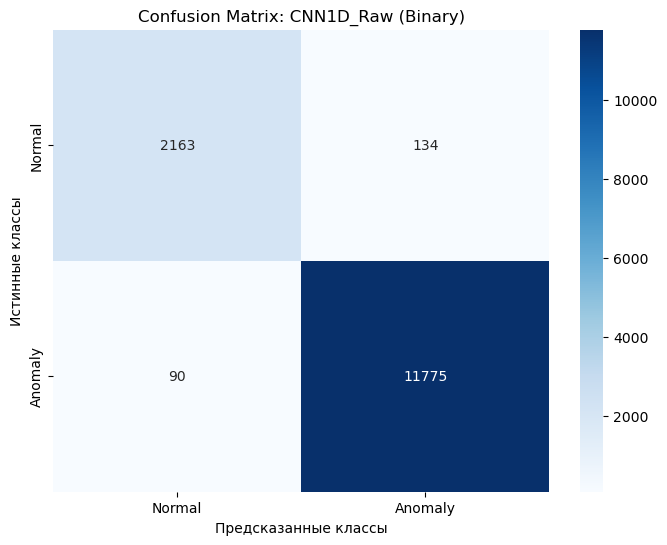

[LSTM_Raw] Точность: 98.16%


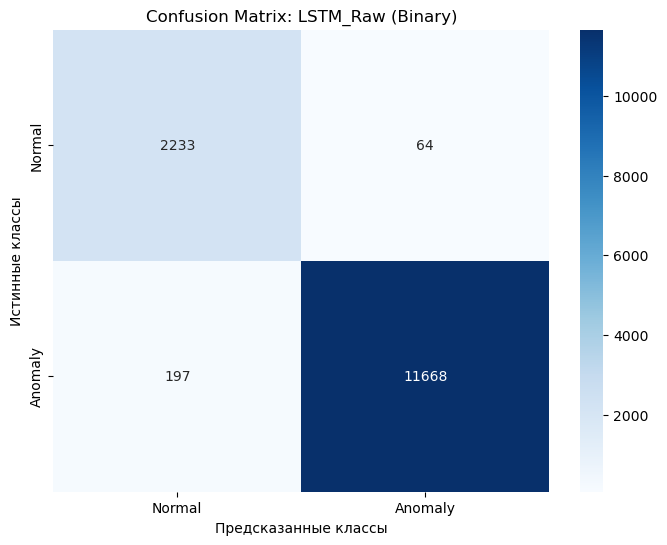


--- РЕЖИМ: МУЛЬТИКЛАСС ---
[CNN1D_Raw] Точность: 22.64%


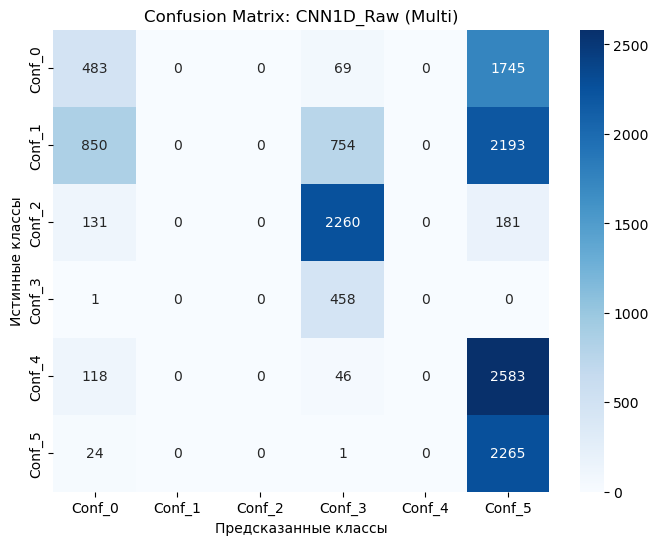

[LSTM_Raw] Точность: 28.87%


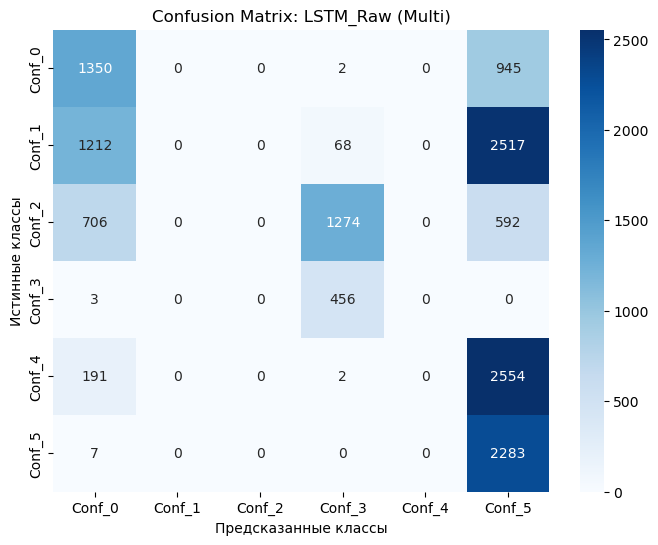

In [15]:
import os
import pandas as pd
import numpy as np
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def load_raw_dataset_honest(base_path, window_size=32, overlap=0.75):
    train_x, train_y = [], []
    test_x, test_y = [], []
    cols = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
    step = int(window_size * (1 - overlap))

    for class_id in range(6):
        dir_path = os.path.join(base_path, f"Configuration_{class_id}")
        if not os.path.exists(dir_path): continue
            
        files = sorted([f for f in os.listdir(dir_path) if f.endswith('.csv')])
        split_idx = int(len(files) * 0.8)
        train_files = files[:split_idx]
        test_files = files[split_idx:]

        def get_windows_from_files(file_list):
            windows = []
            for f in file_list:
                df = pd.read_csv(os.path.join(dir_path, f))[cols]
                data = df.values
                for i in range(0, len(data) - window_size + 1, step):
                    windows.append(data[i : i + window_size])
            return windows

        tr_win = get_windows_from_files(train_files)
        ts_win = get_windows_from_files(test_files)

        if tr_win:
            train_x.append(np.array(tr_win, dtype=np.float32))
            train_y.append(np.full(len(tr_win), class_id))
        if ts_win:
            test_x.append(np.array(ts_win, dtype=np.float32))
            test_y.append(np.full(len(ts_win), class_id))

    X_train = np.vstack(train_x)
    y_train = np.concatenate(train_y)
    X_test = np.vstack(test_x)
    y_test = np.concatenate(test_y)

    scaler = StandardScaler()
    n_tr, ws, ft = X_train.shape
    X_train = scaler.fit_transform(X_train.reshape(-1, ft)).reshape(n_tr, ws, ft)
    X_test = scaler.transform(X_test.reshape(-1, ft)).reshape(-1, ws, ft)

    return X_train, X_test, y_train, y_test

class CNN1DRaw(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(6, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.net(x.transpose(1, 2))

class LSTMRaw(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.embedding = nn.Linear(6, 64)
        self.lstm = nn.LSTM(64, 64, num_layers=2, batch_first=True)
        self.fc = nn.Linear(64, num_classes)
    def forward(self, x):
        x = self.embedding(x)
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1])

def plot_confusion_matrix(y_true, y_pred, title, labels):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix: {title}')
    plt.ylabel('Истинные классы')
    plt.xlabel('Предсказанные классы')
    plt.show()

def run_raw_analysis(is_binary=True):
    path = "DATA/flights_trimmed_imu"
    # Используем честный загрузчик
    X_train, X_test, y_train, y_test = load_raw_dataset_honest(path)

    if is_binary:
        y_train = (y_train != 0).astype(int)
        y_test = (y_test != 0).astype(int)
        n_classes = 2
        labels = ['Normal', 'Anomaly']
    else:
        n_classes = 6
        labels = [f'Conf_{i}' for i in range(6)]

    device = torch.device("cpu")
    print(f"\n--- РЕЖИМ: {'БИНАРНЫЙ' if is_binary else 'МУЛЬТИКЛАСС'} ---")
    
    models = [("CNN1D_Raw", CNN1DRaw), ("LSTM_Raw", LSTMRaw)]

    for name, m_class in models:
        model = m_class(n_classes).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.CrossEntropyLoss()
        
        loader = DataLoader(TensorDataset(torch.Tensor(X_train), torch.LongTensor(y_train)), 
                            batch_size=128, shuffle=True)
        
        model.train()
        for epoch in range(15):
            for bx, by in loader:
                optimizer.zero_grad()
                loss = criterion(model(bx), by)
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            preds = torch.argmax(model(torch.Tensor(X_test)), dim=1).numpy()
            acc = accuracy_score(y_test, preds) * 100
        
        print(f"[{name}] Точность: {acc:.2f}%")
        plot_confusion_matrix(y_test, preds, f"{name} ({'Binary' if is_binary else 'Multi'})", labels)

if __name__ == "__main__":
    run_raw_analysis(is_binary=True)
    run_raw_analysis(is_binary=False)